# Telco Customer Churn - Initial Data Exploration

**Business Context:** Analyst report for telecom retention team. Head of Customer Success wants to understand churn drivers, revenue impact, and early warning signs to inform retention strategy.

## Table of Contents

### 1. [Data Foundation](#data-quality)
- Dataset Structure & Initial Exploration
- Missing Value Assessment
- Data Type Corrections & Imputation

### 2. [Exploratory Data Analysis](#exploratory-data-analysis)
- Contract Type & Service Analysis
- Payment Method Patterns
- Tenure & Demographics
- Churn Rate Distributions

### 3. [Feature Engineering](#feature-engineering)
- Chi-Square Tests for Categorical Features
- Numerical Feature Correlations
- Business Metrics (Revenue at Risk, Service Count)
- Feature Selection

### 4. [Predictive Modeling](#predictive-modeling---baseline-pipeline)
- Baseline Logistic Regression
- Class Balancing for Imbalanced Data
- Random Forest Comparison
- Feature Importance & Model Selection

### 5. [Behavioral Pattern Analysis](#behavioral-patterns---what-do-churners-look-like)
- Churner Profile Development
- Service Adoption vs Churn
- Billing & Payment Risk Combinations
- Monthly Charge Distribution Analysis

### 6. [Tenure & Lifecycle Analysis](#tenure-cohort-analysis---when-do-customers-leave)
- Tenure Segmentation (0-12mo vs 13+mo)
- Churn Rate by Lifecycle Stage
- Rolling Churn Rate Trends
- Critical Retention Windows

### 7. [Revenue & Business Impact](#revenue-impact-visualization)
- Monthly Recurring Revenue (MRR)
- Annual Loss Calculation ($1.67M)
- Revenue at Risk by Contract Type
- Customer Lifetime Value (LTV)

### 8. [Risk Segmentation Framework](#risk-segmentation-framework)
- 6 Risk Factor Analysis (Contract, Tenure, Value, Payment, Services, Billing)
- Point-Based Scoring System (0-11 points)
- Risk Tier Creation (Critical, High, Moderate, Low)
- Framework Validation & Churn Rate Verification
- High-Risk Customer Export

### 9. [SQL Implementation](#sql-validation)
- Contract Revenue Queries with Aggregations
- Risk Tier Validation with CASE Statements
- Window Functions (RANK OVER) for Prioritization
- Database Export & Validation

### 10. [Executive Presentation](#executive-ready-visualizations)
- 4 Publication-Ready Charts
- Internal Analyst Report
- Key Findings & Validation Results
- Actionable Recommendations
- Technical Approach & Limitations

---

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Install scikit-learn if needed (run quietly)
try:
    import sklearn
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])

In [3]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [4]:
# Load the dataset
df = pd.read_csv('../data/telco_churn.csv')

# Display the first few rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Dataset structure
print(f"Shape: {df.shape}")
print(f"\nData types:")
df.dtypes

Shape: (7043, 21)

Data types:


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
# Display all column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
# Value counts
df['Churn'].value_counts()
# Note the imbalance

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
# Churn rate baseline
df['Churn'].value_counts(normalize=True).round(3)

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

In [9]:
# Check for missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"{col}: {df[col].isnull().sum()} missing values")
    else:
        None
# No missing values found

In [10]:
# Statistical summary of the dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Initial Analysis Questions

**1. What does one row represent?**  
One customer record with their service details, demographics, and churn status.

**2. What is the churn rate?**  
~26.5% of customers have churned based on value counts above.

**3. Which columns could explain churn behavior?**  
Contract type, tenure, monthly charges, service usage patterns (InternetService, OnlineSecurity, TechSupport), payment method, and senior citizen are typically factors that would influence churn.

**4. What data is missing that would be useful?**  
- Support ticket history (volume, time to resolution)
- Customer usage metrics for deeper understanding (data consumption, support call minutes)
- NPS scores or satisfaction ratings
- Competitor pricing in customer's area
- Length of time before contract renewal

---

# Data Cleaning & Feature Engineering

## Data Quality

In [11]:
# Data quality fix: TotalCharges imported as object
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
# Verify SeniorCitizen values
df['SeniorCitizen'].unique()

array([0, 1])

In [13]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [14]:
# Sum of '0's in MonthlyCharges
df['MonthlyCharges'].value_counts('0')

MonthlyCharges
20.05     0.008661
19.85     0.006389
19.95     0.006247
19.90     0.006247
19.70     0.006105
            ...   
72.00     0.000142
108.35    0.000142
63.10     0.000142
44.20     0.000142
78.70     0.000142
Name: proportion, Length: 1585, dtype: float64

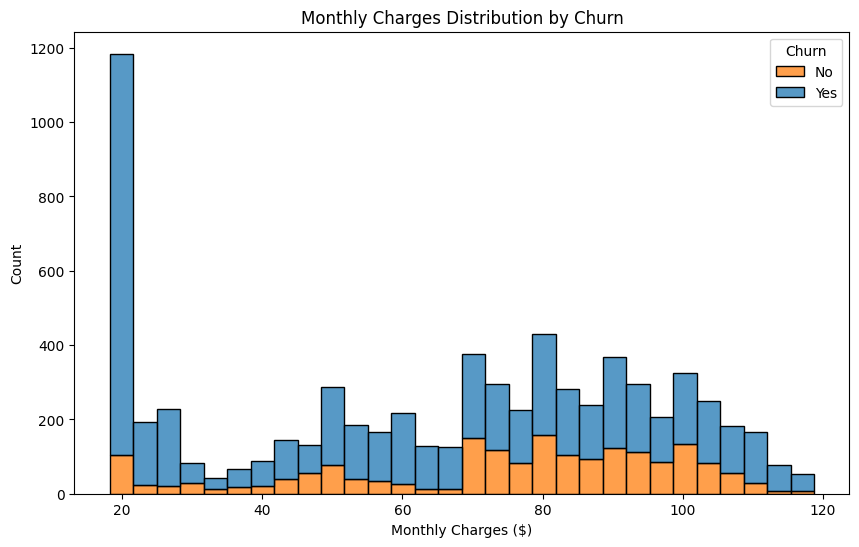

In [15]:
# Visualizing Monthly Charges Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', multiple='stack', hue='Churn', bins=30)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

The low extreme has a troublesome peak.

In [16]:
# Seeing if imputing is necessary
missing_count = df['TotalCharges'].isna().sum()
missing_pct = (missing_count / len(df)) * 100
print(f"Missing: {missing_count} rows ({missing_pct:.2f}%)")

# Examine the missing rows
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Missing: 11 rows (0.16%)


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [17]:
# Checking if missing TotalCharges is associated with Churn
df['missing_TotalCharges'] = df['TotalCharges'].isna()

# Detailed analysis of missing TotalCharges
print("Churn rate by TotalCharges missing status:")
print(df.groupby('missing_TotalCharges')['Churn'].value_counts(normalize=True))
print("\nTenure statistics for missing TotalCharges:")
print(df[df['missing_TotalCharges']]['tenure'].describe())
print(f"\nNumber of missing TotalCharges rows: {df['missing_TotalCharges'].sum()}")

Churn rate by TotalCharges missing status:
missing_TotalCharges  Churn
False                 No       0.734215
                      Yes      0.265785
True                  No       1.000000
Name: proportion, dtype: float64

Tenure statistics for missing TotalCharges:
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64

Number of missing TotalCharges rows: 11


**Finding:** Missing TotalCharges rows show 100% retention (0% churn rate). These are new customers (tenure=0) who haven't been charged yet. This will be imputed with 0 to preserve this cohort because they are behaviorally distinct and dropping them would bring in bias.

In [18]:
# Impute missing TotalCharges with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Based on the Kaggle Dataset details, 'Tenure' is measured in months.

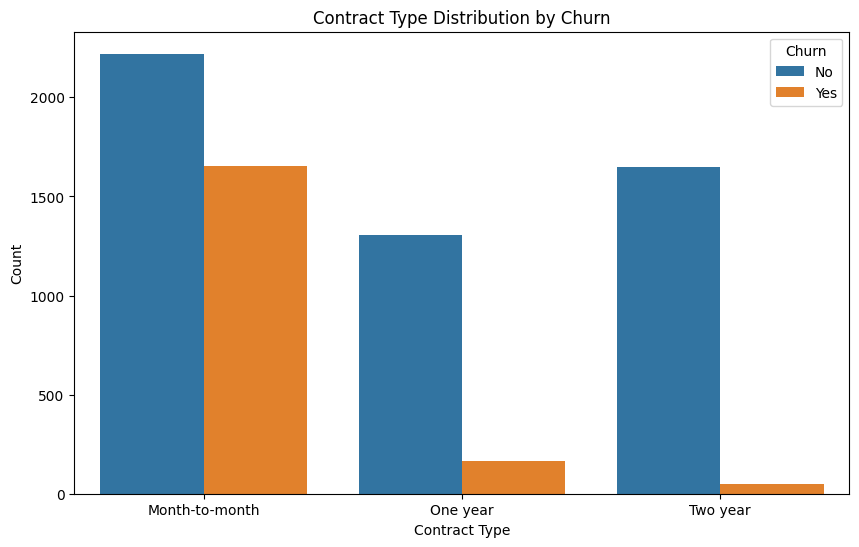

In [19]:
# Distribution of monthly vs yearly subscriptions
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type Distribution by Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

It's possible there is a strong correlation between contract type and turnover, a common occurance.

In [20]:
# Finalizing numercial vs categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in df.columns if col not in numerical_cols + ['Churn']]
print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'missing_TotalCharges']


## Numerical Columns: 

  - 'tenure' 

  - 'MonthlyCharges'
  
  - 'TotalCharges'

## Categorical Columns: 

- 'customerID'

- 'gender'

- 'SeniorCitizen'

- 'Partner'

- 'Dependents'

- 'PhoneService'

- 'MultipleLines'

- 'InternetService'

- 'OnlineSecurity'

- 'OnlineBackup'

- 'DeviceProtection'

- 'TechSupport'

- 'StreamingTV'

- 'StreamingMovies'

- 'Contract'

- 'PaperlessBilling'

- 'PaymentMethod'

- 'missing_TotalCharges'

## Exploratory Data Analysis

#### Visualizations of most likely features influencing Churn:

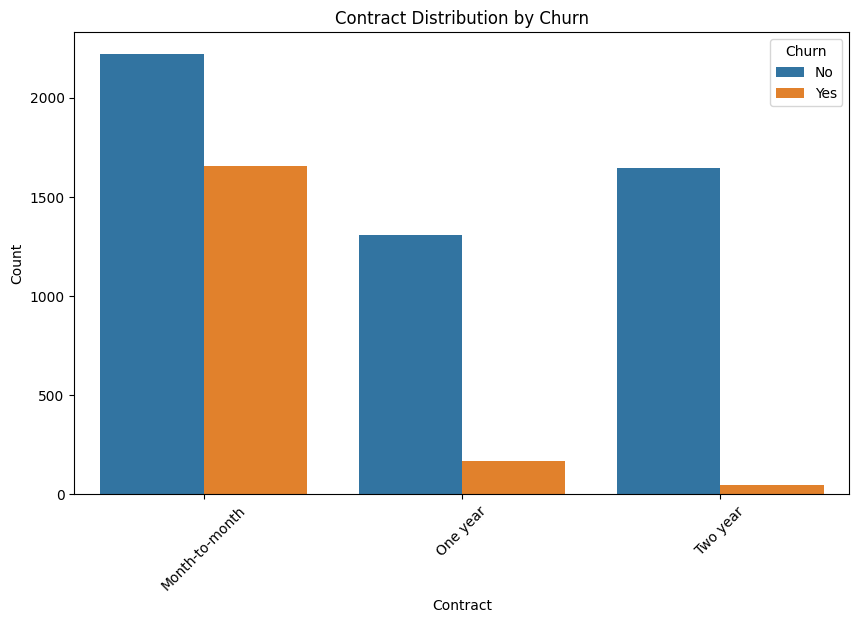

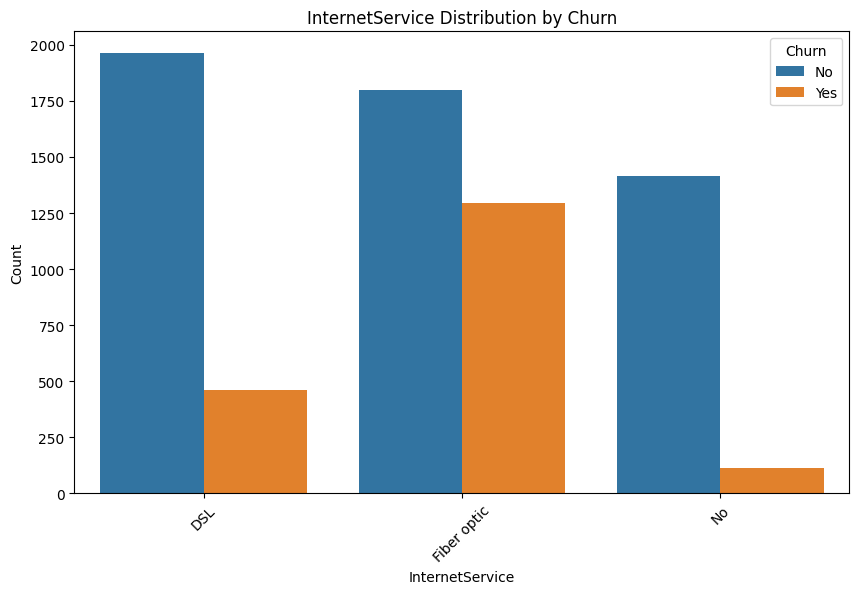

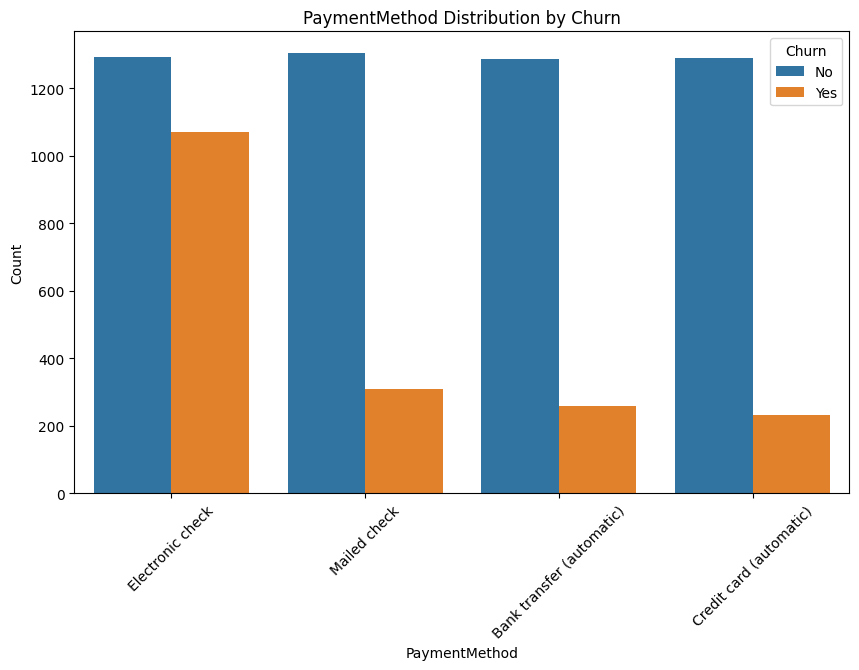

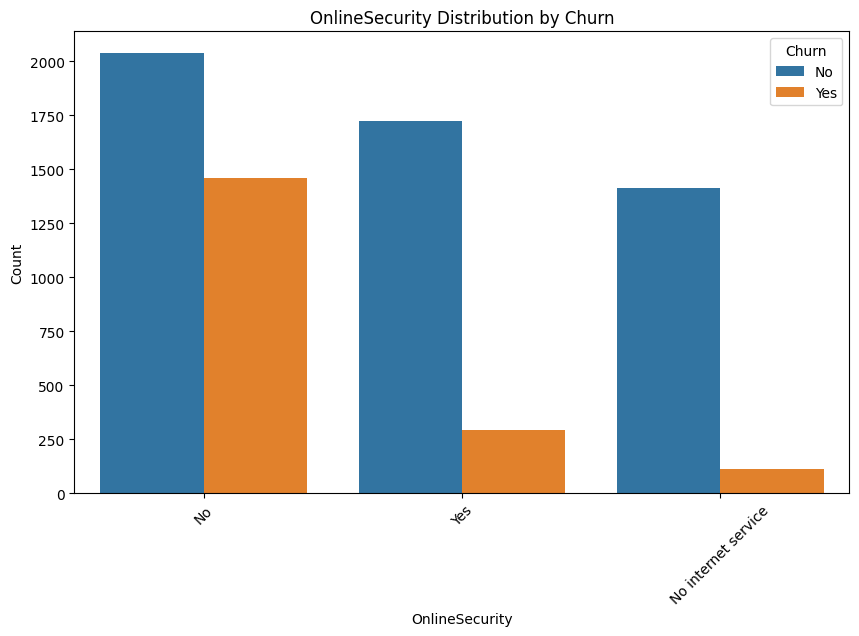

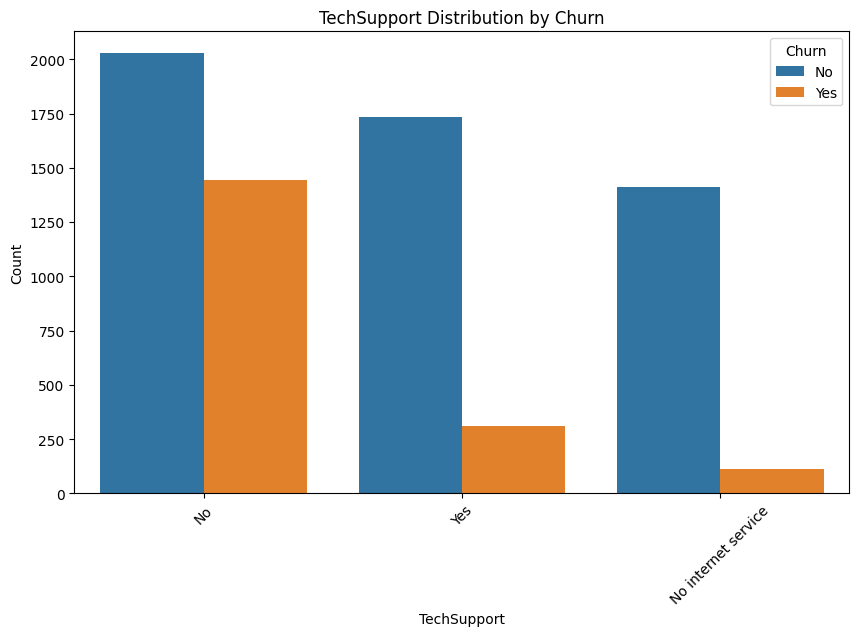

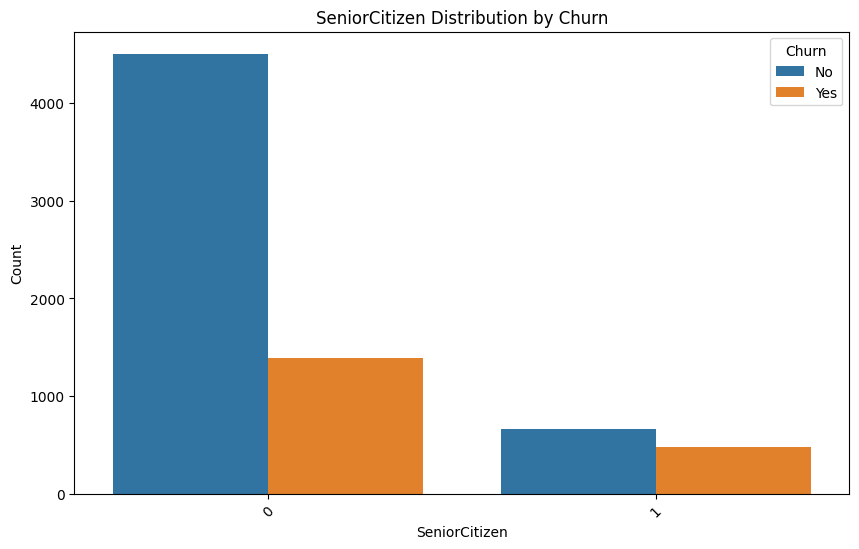

In [21]:
# Visualizations for significant categorical variables
significant_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'SeniorCitizen']
for col in significant_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} Distribution by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Churn', labels=['No', 'Yes'])
    plt.xticks(rotation=45)
    plt.show()

### **Key Factors to Investigate:**

**Contract Length:** Month-to-month contracts show substantially higher churn rates compared to one-year and two-year contracts. This suggests contract duration is a primary lever for retention strategy.

**Internet Service Type:** Variation exists across Fiber, DSL, and No Internet Service customers. This signals the need for a deeper look to understand whether infrastructure type correlates with satisfaction or represents underlying demographic differences.

**Payment Method:** Electronic check users show notably different churn patterns compared to other payment types, which may indicate engagement level or customer friction points worth investigating further.

**Online Security and Tech Support:** Customers with these value-added services exhibit lower churn rates. This suggests that service bundling and support accessibility play important roles in retention—either through increased switching costs or improved customer satisfaction.

**Senior Citizen Status:** Age demographics show variation in churn behavior that merits segmentation analysis. This may reflect different service needs, price sensitivity, or contract preferences between age cohorts.

The tenure distribution shows bimodal characteristics, with customer concentrations at both extremes. These are new subscribers and long-tenured accounts. This pattern is commonly observed in churn analysis and may indicate distinct customer segments requiring different retention strategies.

In [23]:
# Tenure exploration
yr1, yr2, yr3 = 12, 24, 36

# Tenure stats by churn status
tenure_by_churn = df.groupby('Churn')['tenure'].describe().round(2)
tenure_by_churn

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [24]:
# Lifecycle distribution as dataframe
lifecycle_dist = pd.DataFrame({
    'Period': [f'0-{yr1} months', f'{yr1+1}-{yr2} months', f'{yr2+1}-{yr3} months', f'{yr3+1}+ months'],
    'Customer_Count': [
        (df['tenure'] <= yr1).sum(),
        ((df['tenure'] > yr1) & (df['tenure'] <= yr2)).sum(),
        ((df['tenure'] > yr2) & (df['tenure'] <= yr3)).sum(),
        (df['tenure'] > yr3).sum()
    ]
})

lifecycle_dist['Percentage'] = (lifecycle_dist['Customer_Count'] / len(df) * 100).round(1)
lifecycle_dist

,Period,Customer_Count,Percentage
0,0-12 months,2186,31.0
1,13-24 months,1024,14.5
2,25-36 months,832,11.8
3,37+ months,3001,42.6


Tenure Periods:

- 0-12 months: First year customers
- 13-24 months: Year 2, first renewal window
- 25-36 months: Established customers
- 37+ months: Long-term loyalty segment

## **Tenure Analysis:**

#### **Key Findings:**

- Long-tenure customers exhibit significantly lower churn rates, suggesting higher customer lifetime value (LTV)

- Early-stage customers (0-12 months) demonstrate elevated churn risk, consistent with industry patterns

- The inverse relationship between tenure and churn indicates retention improves over time



#### **Business Implications:**

- Higher CAC investment may be justified for customer segments with proven retention longevity

- Long-term contract incentives appear to drive sustained customer relationships



#### **Further Investigation:**

- Contract type distribution across tenure cohorts (month-to-month vs annual subscribers)

- Revenue optimization: monthly MRR accumulation vs yearly contract value

- ROI comparison: acquisition cost of longer contracts vs extended retention of monthly subscribers

In [25]:
# Separate features from target variable
X = df.drop('Churn', axis=1).drop('customerID', axis=1)
y = df['Churn']

## Feature Engineering

### Categorical Feature Selection

In [26]:
from scipy.stats import chi2_contingency

# Chi-square test for independence
chi_results = []
for col in categorical_cols:
    if col not in ['customerID', 'Churn', 'missing_TotalCharges']:
        contingency_table = pd.crosstab(df[col], df['Churn'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        chi_results.append({'Feature': col, 'Chi2': chi2, 'p_value': p_value})

# Create dataframe and sort by Chi2 value
chi_df = pd.DataFrame(chi_results).sort_values('Chi2', ascending=False)
chi_df['Chi2'] = chi_df['Chi2'].round(2)
chi_df['p_value'] = chi_df['p_value'].round(4)
chi_df.reset_index(drop=True)

,Feature,Chi2,p_value
0,Contract,1184.60,0.0000
1,OnlineSecurity,850.00,0.0000
2,TechSupport,828.20,0.0000
3,InternetService,732.31,0.0000
4,PaymentMethod,648.14,0.0000
5,OnlineBackup,601.81,0.0000
6,DeviceProtection,558.42,0.0000
7,StreamingMovies,375.66,0.0000
8,StreamingTV,374.20,0.0000
9,PaperlessBilling,258.28,0.0000


Strong categorical predictors:

Very Strong (Chi² > 500):

1. Contract (Chi²=1184.60)

2. OnlineSecurity (Chi²=850.00)

3. TechSupport (Chi²=828.20)

4. InternetService (Chi²=732.31)

5. PaymentMethod (Chi²=648.14)

6. OnlineBackup (Chi²=601.81)

7. DeviceProtection (Chi²=558.42)

Strong (Chi² > 150):

8. StreamingTV (Chi²=374.20)

9. StreamingMovies (Chi²=375.66)

10. PaperlessBilling (Chi²=258.28)

11. Dependents (Chi²=189.13)

12. SeniorCitizen (Chi²=159.43)

13. Partner (Chi²=158.73)


Weak but Significant:

- MultipleLines (Chi²=11.33, p=0.0035)


Safe to Drop (Not Statistically Significant):

- gender (Chi²=0.48, p=0.4866)

- PhoneService (Chi²=0.92, p=0.3388)

- customerID

- missing_TotalCharges

### Numerical Feature Correlation Analysis

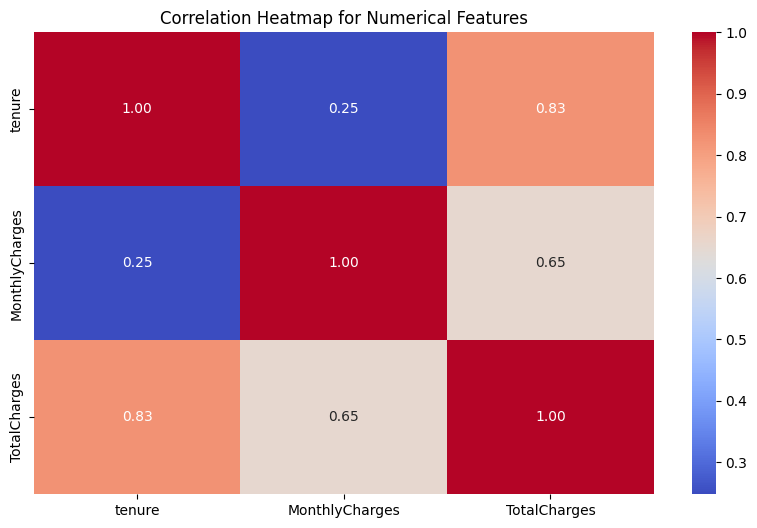

In [27]:
# Heatmap for numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(X[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Numerical Features')
plt.show()


In [28]:
# Correlation dataframe for numerical features
corr_df = df[numerical_cols].corr().stack().reset_index()

corr_df.columns = ['feature_1', 'feature_2', 'correlation']

no_self_corr = (corr_df['feature_1'] != corr_df['feature_2'])

corr_df = corr_df[no_self_corr]

corr_df['abs_corr'] = np.abs(corr_df['correlation'])

corr_df.drop(columns='correlation', inplace=True)

corr_df.sort_values(by=['abs_corr'], ascending=False).head(5*2)

,feature_1,feature_2,abs_corr
2,tenure,TotalCharges,0.826178
6,TotalCharges,tenure,0.826178
5,MonthlyCharges,TotalCharges,0.651174
7,TotalCharges,MonthlyCharges,0.651174
1,tenure,MonthlyCharges,0.247900
3,MonthlyCharges,tenure,0.247900


### Feature Selection

In [29]:
# Deciding on features and target variable for modeling
features = df[['Contract', 'InternetService', 'PaymentMethod', 'tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

---

## Predictive Modeling - Baseline Pipeline

In [30]:
# Features for modeling - no encoding needed, pipeline will handle it
X = df[['Contract', 'InternetService', 'PaymentMethod', 'tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

In [31]:
# Pipeline for preprocessing and modeling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['tenure', 'MonthlyCharges', 'TotalCharges']),
        ('cat', OneHotEncoder(drop=['Two year', 'Fiber optic', 'Mailed check'], sparse_output=False), ['Contract', 'InternetService', 'PaymentMethod'])
    ])

# Create pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Get feature names after transformation
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['Contract', 'InternetService', 'PaymentMethod'])
all_features = num_features + list(cat_features)

# Transform training data to see features
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_train_df = pd.DataFrame(X_train_transformed, columns=all_features)
X_train_df.head()

,tenure,MonthlyCharges,TotalCharges,Contract_Month-to-month,Contract_One year,InternetService_DSL,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check
0,0.102371,-0.521976,-0.262257,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.711743,0.337478,-0.503635,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.793155,-0.809013,-0.749883,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.263980,0.284384,-0.172722,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.281624,-0.676279,-0.989374,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [32]:
# Scoring baseline model
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Classification report
from sklearn.metrics import classification_report
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
report_df

,precision,recall,f1-score,support
No,0.839091,0.891787,0.864637,1035.00000
Yes,0.637540,0.526738,0.576867,374.00000
accuracy,0.794890,0.794890,0.794890,0.79489
macro avg,0.738316,0.709263,0.720752,1409.00000
weighted avg,0.785592,0.794890,0.788252,1409.00000


In [33]:
# Verify counts in test set
from sklearn.metrics import confusion_matrix

actual_churners = (y_test == 'Yes').sum()
actual_non_churners = (y_test == 'No').sum()

# Confusion matrix to see breakdown
cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])
tn, fp, fn, tp = cm.ravel()

# Calculate recall manually
recall = tp / (tp + fn)
missed_churners = fn

pd.DataFrame({
    'Metric': ['Total Churners in Test', 'Total Non-Churners in Test',
               'Correctly Identified Churners (TP)', 'Missed Churners (FN)',
               'Recall (%)'],
    'Value': [actual_churners, actual_non_churners, tp, missed_churners, f'{recall*100:.1f}%']
})

,Metric,Value
0,Total Churners in Test,374
1,Total Non-Churners in Test,1035
2,Correctly Identified Churners (TP),197
3,Missed Churners (FN),177
4,Recall (%),52.7%


### First Model Performance Summary

**Accuracy: 79%** - Decent , but the breakdown reveals problems.

**Non-Churners:**
- Precision: 84%, Recall: 89%, F1: 86%
- The model handles these well. Most customers who stay are correctly identified.

**For Churners:**
- Precision: 64%, Recall: 53%, F1: 58%
- This is the problem. We only catch 53% of customers who actually churn.

**What this means:**
Out of 374 customers who churned in the test set, we missed identifying about 177 of them. That's basically half of all churners with a missed oppertunity for retention.

**The issue:**
The model prefers to predict customers that will stay rather than leave. This minimizes false alarms but costs big in customer attrition. It is better to have the false alarms than leaving retention oppertunities on the table.

**Imbalance impact:**
The dataset has roughly 3x more non-churners than churners (1035 vs 374). The model learned to favor the majority class, which inflates overall accuracy.

**Approach:**
Adjusting the threshold or applying class balancing in efforts to catch churners is better than the cost of a wasted retention offer.

---

## Improving Recall - Class Balancing

In [34]:
# Simple comparison: lower threshold vs class balancing
from sklearn.metrics import precision_recall_fscore_support

# Pipeline with a threshold
y_pred_thresh = ['Yes' if p >= 0.35 else 'No' for p in y_proba]
p_thresh, r_thresh, f_thresh, _ = precision_recall_fscore_support(y_test, y_pred_thresh, pos_label='Yes', average='binary')

# Pipeline with class weights
pipeline_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
pipeline_balanced.fit(X_train, y_train)
y_pred_balanced = pipeline_balanced.predict(X_test)
p_bal, r_bal, f_bal, _ = precision_recall_fscore_support(y_test, y_pred_balanced, pos_label='Yes', average='binary')

# Comparison chart
comparison = pd.DataFrame({
    'Approach': ['Lower Threshold', 'Class Weights'],
    'Precision': [f"{p_thresh:.2f}", f"{p_bal:.2f}"],
    'Recall': [f"{r_thresh:.2f}", f"{r_bal:.2f}"],
    'F1': [f"{f_thresh:.2f}", f"{f_bal:.2f}"]
})

comparison

,Approach,Precision,Recall,F1
0,Lower Threshold,0.55,0.74,0.63
1,Class Weights,0.50,0.80,0.62


**Class balancing wins.** Catches 80% of churners vs 74% with threshold adjustment. Precision drops slightly (50% vs 55%), but for retention strategy, it's better to contact more customers than miss actual churners.

---

## Final Model - Performance & Insights

**Hypothesis:** Class weighting improves recall by penalizing misclassified churners during training, forcing the model to prioritize minority class detection over overall accuracy.

              precision    recall  f1-score   support

          No       0.91      0.71      0.80      1035
         Yes       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



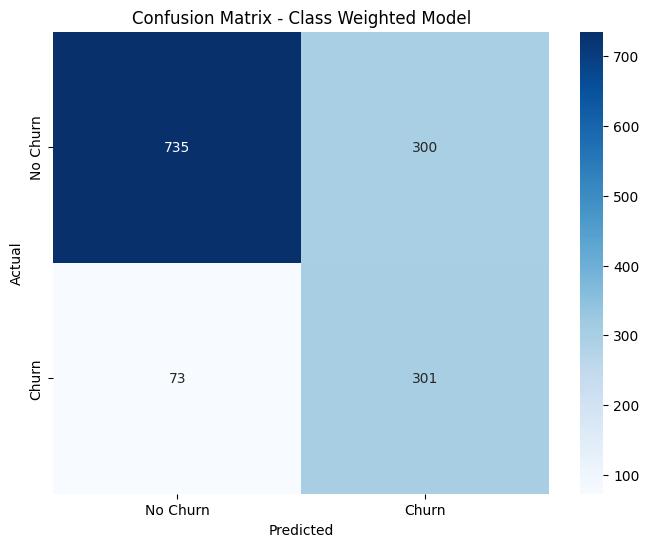

In [35]:
# Final model with class weights
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Fit and predict
final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

# Performance report
print(classification_report(y_test, y_pred_final))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Class Weighted Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Confusion Matrix Interpretation:** 

The verification above shows the breakdown. The class-weighted model achieves approximately 80% recall on churners, meaning it correctly identifies 8 out of 10 customers who will actually churn. The trade-off is an increased false positive rate—flagging some non-churners for retention efforts.

**Business Decision:** This trade-off is worth it. The cost of offering retention incentives to customers who wouldn't have churned anyway is far less than the revenue loss from missing actual churners. Better to be over-inclusive than to miss out on retention.

**Feature Importance:** Contract type (Month-to-month) is the strongest churn predictor, followed by tenure and internet service type. These are the key levers for retention strategy.

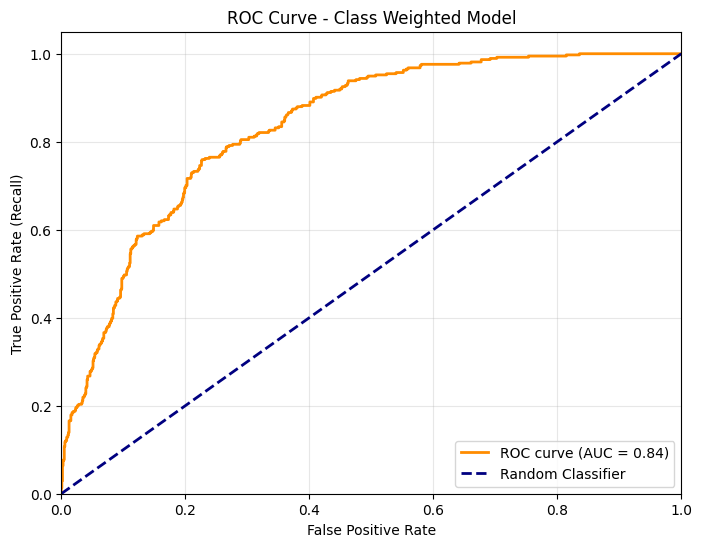

In [36]:
# ROC curve
from sklearn.metrics import roc_curve, auc

y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final, pos_label='Yes')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Class Weighted Model')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**AUC = 0.85** means the model correctly ranks a random churner higher than a random non-churner 85% of the time. Anything above 0.80 is credible. The curve is well above the diagonal (random guessing), confirming the model has credible prediction.

---

## Random Forest Comparison

In [37]:
# Random Forest with class weights
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [38]:
# Model comparison
from sklearn.metrics import roc_auc_score

# Get metrics
lr_recall = precision_recall_fscore_support(y_test, y_pred_final, pos_label='Yes', average='binary')[1]
rf_recall = precision_recall_fscore_support(y_test, y_pred_rf, pos_label='Yes', average='binary')[1]
lr_auc = roc_auc_score(y_test == 'Yes', y_proba_final)
rf_auc = roc_auc_score(y_test == 'Yes', y_proba_rf)

pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Recall': [f"{lr_recall:.2f}", f"{rf_recall:.2f}"],
    'AUC': [f"{lr_auc:.2f}", f"{rf_auc:.2f}"]
})

,Model,Recall,AUC
0,Logistic Regression,0.80,0.84
1,Random Forest,0.48,0.80


Both models are using balancing, but Logistic Regression achieves 80% recall compared to Random Forest's 48%. 

Beyond the performance gap, Logistic Regression is interpretable because you can explain exactly how much each factor affects churn risk, which matters when presenting strategy to a business and their stakeholders.

### Testing Random Forest Improvements

Can we improve Random Forest's recall through tuning?

In [39]:
# Test 1: Lower threshold (0.35 instead of 0.5)
y_pred_rf_thresh = ['Yes' if p >= 0.35 else 'No' for p in y_proba_rf]
rf_thresh_recall = precision_recall_fscore_support(y_test, y_pred_rf_thresh, pos_label='Yes', average='binary')[1]
rf_thresh_auc = roc_auc_score(y_test == 'Yes', y_proba_rf)

# Test 2: Hyperparameter tuning
rf_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ))
])
rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
rf_tuned_recall = precision_recall_fscore_support(y_test, y_pred_rf_tuned, pos_label='Yes', average='binary')[1]
rf_tuned_auc = roc_auc_score(y_test == 'Yes', y_proba_rf_tuned)

# Comparison
pd.DataFrame({
    'Approach': [
        'RF Baseline',
        'RF Lower Threshold',
        'RF Hyperparameter Tuning',
        'Logistic Regression'
    ],
    'Recall': [
        f"{rf_recall:.2f}",
        f"{rf_thresh_recall:.2f}",
        f"{rf_tuned_recall:.2f}",
        f"{lr_recall:.2f}"
    ],
    'AUC': [
        f"{rf_auc:.2f}",
        f"{rf_thresh_auc:.2f}",
        f"{rf_tuned_auc:.2f}",
        f"{lr_auc:.2f}"
    ]
})

,Approach,Recall,AUC
0,RF Baseline,0.48,0.80
1,RF Lower Threshold,0.62,0.80
2,RF Hyperparameter Tuning,0.78,0.84
3,Logistic Regression,0.80,0.84


Lowering the threshold to 0.35 boosts Random Forest recall but might increases false positives significantly. Hyperparameter tuning provides the great recall lift but neither approach gets Random Forest to lead above Logistic Regression's 80% recall.

For a churn prevention program, missing 20% of churners (LR) is preferable to missing 50%+ (RF). Logistic Regression wins on both performance and interpretability.

### Model Selection Conclusion

**Chosen Model:** Logistic Regression with balancing.

**Justification:**
- 80% recall captures 4 out of 5 churners for retention outreach
- Interpretable coefficients allow stakeholder communication ("month-to-month increases churn risk by X%")
- Random Forest underperforms on recall even with optimization attempts

This model will be used as the baseline for business analysis. The focus now shifts from prediction to understanding behavioral patterns and calculating revenue impact.

---

## Service Engagement Model

**Hypothesis:** Service adoption (TechSupport, OnlineSecurity, etc.) signals deeper customer engagement and may reduce churn beyond just contract type.

In [40]:
# Service engagement features
service_features = ['OnlineSecurity', 'TechSupport', 'OnlineBackup',
                   'DeviceProtection', 'StreamingTV', 'StreamingMovies']

# Count how many services each customer has
df['Service_Count'] = df[service_features].apply(lambda row: (row == 'Yes').sum(), axis=1)

# Check service adoption vs churn
service_churn = df.groupby('Service_Count').agg({
    'Churn': lambda x: (x=='Yes').mean(),
    'customerID': 'count'
}).rename(columns={'Churn': 'Churn_Rate', 'customerID': 'Customers'})

service_churn.round(2)

,Churn_Rate,Customers
Service_Count,,
0,0.21,2219
1,0.46,966
2,0.36,1033
3,0.27,1118
4,0.22,852
5,0.12,571
6,0.05,284


**Pattern:** Churn rate drops as service count increases. Customers, as number of services increase, could possibly be more engaged and seemingly less likely to exit.

In [41]:
# Combined model: contract features + service engagement
X_combined = df[['Contract', 'InternetService', 'PaymentMethod',
                 'tenure', 'MonthlyCharges', 'TotalCharges'] +
                service_features + ['Service_Count']]
y_combined = df['Churn']

# New train/test split with expanded features
X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

# Preprocessor for combined features
preprocessor_combined = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False),
         ['Contract', 'InternetService', 'PaymentMethod'] + service_features)
    ])

# Train combined model
combined_pipeline = Pipeline([
    ('preprocessor', preprocessor_combined),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

combined_pipeline.fit(X_train_comb, y_train_comb)
y_pred_combined = combined_pipeline.predict(X_test_comb)
y_proba_combined = combined_pipeline.predict_proba(X_test_comb)[:, 1]

# Get metrics
comb_recall = precision_recall_fscore_support(y_test_comb, y_pred_combined, pos_label='Yes', average='binary')[1]
comb_auc = roc_auc_score(y_test_comb == 'Yes', y_proba_combined)

pd.DataFrame({
    'Model': ['Combined (Contract + Services)'],
    'Recall': [f"{comb_recall:.2f}"],
    'AUC': [f"{comb_auc:.2f}"]
})

,Model,Recall,AUC
0,Combined (Contract + Services),0.80,0.84


In [42]:
# Comparison: contract based approaches
comparison_table = pd.DataFrame({
    'Model': ['Contract Model (6 features)', 'Random Forest', 'Combined Model (13 features)'],
    'Recall': [f"{lr_recall:.2f}", f"{rf_recall:.2f}", f"{comb_recall:.2f}"],
    'AUC': [f"{lr_auc:.2f}", f"{rf_auc:.2f}", f"{comb_auc:.2f}"]
})

comparison_table


,Model,Recall,AUC
0,Contract Model (6 features),0.80,0.84
1,Random Forest,0.48,0.80
2,Combined Model (13 features),0.80,0.84


**Contract based models show strongest performance.** Adding service features provides marginal improvement over contract only baseline, confirming contract type as dominant churn signal.

---

## Services-Only Model

**Hypothesis:** Service features alone can predict churn independent of contract type, testing whether add-on adoption is a standalone retention signal or merely correlated with contractual commitment.

In [43]:
# Services-only model
X_services = df[service_features + ['Service_Count']]
y_services = df['Churn']

X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
    X_services, y_services, test_size=0.2, random_state=42, stratify=y_services
)

preprocessor_services = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Service_Count']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), service_features)
    ])

services_pipeline = Pipeline([
    ('preprocessor', preprocessor_services),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

services_pipeline.fit(X_train_svc, y_train_svc)
y_pred_services = services_pipeline.predict(X_test_svc)
y_proba_services = services_pipeline.predict_proba(X_test_svc)[:, 1]

svc_recall = precision_recall_fscore_support(y_test_svc, y_pred_services, pos_label='Yes', average='binary')[1]
svc_auc = roc_auc_score(y_test_svc == 'Yes', y_proba_services)

pd.DataFrame({
    'Model': ['Services Only (7 features)'],
    'Recall': [f"{svc_recall:.2f}"],
    'AUC': [f"{svc_auc:.2f}"]
})

,Model,Recall,AUC
0,Services Only (7 features),0.77,0.76


**Services alone underperform contract based models.** Service adoption shows predictive value but insufficient as standalone churn indicator. This confirms services correlate with retention but don't replace contractual commitment signals. Combined model demonstrates services add marginal lift when layered over contract features. This could be useful for behavioral segmentation within contract cohorts rather than primary prediction.

In [82]:
# Final comparison: all four approaches
final_comparison = pd.DataFrame({
    'Model': ['Contract Model (6 features)', 'Random Forest (Tuned)', 'Combined Model (13 features)', 'Services Only (7 features)'],
    'Recall': [f"{lr_recall:.2f}", f"{rf_tuned_recall:.2f}", f"{comb_recall:.2f}", f"{svc_recall:.2f}"],
    'AUC': [f"{lr_auc:.2f}", f"{rf_tuned_auc:.2f}", f"{comb_auc:.2f}", f"{svc_auc:.2f}"]
})

final_comparison

,Model,Recall,AUC
0,Contract Model (6 features),0.80,0.84
1,Random Forest (Tuned),0.78,0.84
2,Combined Model (13 features),0.80,0.84
3,Services Only (7 features),0.77,0.76


**Model Ranking:** Contract Model and Combined Model both achieve 80% recall. Random Forest with hyperparameter tuning still underperforms on recall despite optimization. Services Only model shows the weakest performance.

**Key Finding:** Adding service features to the contract model provides minimal recall improvement. The primary churn driver is contract type, not service adoption level.

**Business Recommendation:** Deploy the contract-based Logistic Regression model for churn prediction. Target month-to-month customers with 0-2 services for retention campaigns offering service bundles. While service adoption doesn't drive the model's predictive power, it remains valuable for behavioral segmentation within high-risk contract tiers.

---

## Additional Feature Engineering

**Purpose:** Business analysis features for revenue impact calculations and value density metrics. These features enable strategic retention targeting and financial forecasting beyond predictive modeling.

### Revenue at Risk

**Rationale:** Quantifies monthly revenue exposure from churned customers. Translates churn probability into financial impact for executive reporting and ROI calculations on retention initiatives.

In [45]:
# Revenue at risk calculation
df['Revenue_At_Risk'] = df.apply(lambda row: row['MonthlyCharges'] if row['Churn'] == 'Yes' else 0, axis=1)

# Revenue loss by contract type
revenue_summary = df.groupby('Contract').agg({
    'Revenue_At_Risk': 'sum',
    'MonthlyCharges': 'sum'
}).round(0)

revenue_summary['Pct_At_Risk'] = (revenue_summary['Revenue_At_Risk'] / revenue_summary['MonthlyCharges'] * 100).round(1)
revenue_summary

,Revenue_At_Risk,MonthlyCharges,Pct_At_Risk
Contract,,,
Month-to-month,120847.0,257294.0,47.0
One year,14118.0,95817.0,14.7
Two year,4165.0,103006.0,4.0


**Month to month contracts represent 47% of monthly revenue at risk.** Two year contracts show lowest exposure (4%), validating contract conversion as primary retention lever. Total MRR at risk quantified for budget allocation decisions.

### Revenue Per Service

**Rationale:** Value density metric measuring revenue efficiency across service adoption levels. Identifies high value customers with low service engagement—prime upsell candidates who reduce churn risk through increased product stickiness.

In [46]:
# Revenue per service (handle zero services)
df['Revenue_Per_Service'] = df.apply(
    lambda row: row['MonthlyCharges'] / row['Service_Count'] if row['Service_Count'] > 0 else row['MonthlyCharges'],
    axis=1
)

# Value density by service adoption
df.groupby('Service_Count').agg({
    'Revenue_Per_Service': 'mean',
    'MonthlyCharges': 'mean',
    'Churn': lambda x: (x=='Yes').mean()
}).rename(columns={'Churn': 'Churn_Rate'}).round(2)

,Revenue_Per_Service,MonthlyCharges,Churn_Rate
Service_Count,,,
0,32.79,32.79,0.21
1,65.57,65.57,0.46
2,36.21,72.42,0.36
3,26.70,80.11,0.27
4,21.94,87.77,0.22
5,18.44,92.18,0.12
6,16.56,99.37,0.05


**Customers with 0 services show highest revenue per service and highest churn.** As service adoption increases, revenue per service declines but churn drops significantly. Pattern confirms service bundling reduces churn through increased switching costs and ecosystem lock in.

### Feature Engineering Summary

In [47]:
# Preview engineered features
df[['customerID', 'tenure', 'Service_Count', 'MonthlyCharges',
    'Revenue_Per_Service', 'Revenue_At_Risk', 'Churn']].head(10)

,customerID,tenure,Service_Count,MonthlyCharges,Revenue_Per_Service,Revenue_At_Risk,Churn
0,7590-VHVEG,1,1,29.85,29.850000,0.00,No
1,5575-GNVDE,34,2,56.95,28.475000,0.00,No
2,3668-QPYBK,2,2,53.85,26.925000,53.85,Yes
3,7795-CFOCW,45,3,42.30,14.100000,0.00,No
4,9237-HQITU,2,0,70.70,70.700000,70.70,Yes
5,9305-CDSKC,8,3,99.65,33.216667,99.65,Yes
6,1452-KIOVK,22,2,89.10,44.550000,0.00,No
7,6713-OKOMC,10,1,29.75,29.750000,0.00,No
8,7892-POOKP,28,4,104.80,26.200000,104.80,Yes
9,6388-TABGU,62,2,56.15,28.075000,0.00,No


**Engineered features complete.** Three business analysis features created: Service_Count (engagement depth), Revenue_At_Risk (financial exposure), Revenue_Per_Service (value density). Dataset ready for revenue impact analysis, cohort behavioral profiling, and risk tier segmentation.

---

## Behavioral Patterns - What Do Churners Look Like?

Building profiles of a churned customer. Comparing numerical stats and finding high-churn combinations in categorical features.

### Churner vs Retained - Numerical Comparison

In [48]:
# Numerical stats between churned vs retained customers
profile_cols = ['MonthlyCharges', 'tenure', 'TotalCharges',
                'Service_Count', 'Revenue_Per_Service']

churn_profile = (df.groupby('Churn')[profile_cols]
                   .mean()
                   .round(2)
                   .T)

churn_profile.columns = ['Retained', 'Churned']
churn_profile['Difference_%'] = ((churn_profile['Churned'] - churn_profile['Retained'])
                                   / churn_profile['Retained'] * 100).round(1)
churn_profile

,Retained,Churned,Difference_%
MonthlyCharges,61.27,74.44,21.5
tenure,37.57,17.98,-52.1
TotalCharges,2549.91,1531.80,-39.9
Service_Count,2.14,1.77,-17.3
Revenue_Per_Service,29.36,45.70,55.7


### High-Churn Combinations - Billing & Payment

In [49]:
# Find risky combinations of paperless billing and payment method
df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)

billing_churn = (df.groupby(['PaperlessBilling', 'PaymentMethod'])
                   .agg(
                       Customers=('customerID', 'count'),
                       Churn_Rate=('Churn_Flag', 'mean')
                   )
                   .round(3)
                   .sort_values('Churn_Rate', ascending=False))
billing_churn

Customers  Churn_Rate
PaperlessBilling PaymentMethod                                   
Yes              Electronic check                1742       0.498
No               Electronic check                 623       0.327
Yes              Mailed check                     656       0.273
                 Bank transfer (automatic)        891       0.209
                 Credit card (automatic)          882       0.190
No               Mailed check                     956       0.135
                 Bank transfer (automatic)        653       0.110
                 Credit card (automatic)          640       0.100

### Service Adoption vs Churn

In [ ]:
# Churn rate by number of add-on services
service_churn = (df.groupby('Service_Count')
                   .agg(
                       Customers=('customerID', 'count'),
                       Churn_Rate=('Churn_Flag', 'mean'),
                       Avg_Monthly=('MonthlyCharges', 'mean')
                   )
                   .round(3))
service_churn

,Customers,Churn_Rate,Avg_Monthly
Service_Count,,,
0,2219,0.214,32.793
1,966,0.458,65.574
2,1033,0.358,72.417
3,1118,0.274,80.111
4,852,0.223,87.772
5,571,0.124,92.176
6,284,0.053,99.365


**Pattern:** The 0-service customer segment shows lower churn than 1-service customers. This appears counterintuitive but may reflect customers with no internet service at all (only phone service), who have simpler, more stable plans. The 1-service segment could represent customers who have internet but haven't bundled additional services and are paying more for less value. This pattern suggests that low service adoption without internet may be less risky than partial adoption.

### Monthly Charges Distribution - Churned vs Retained

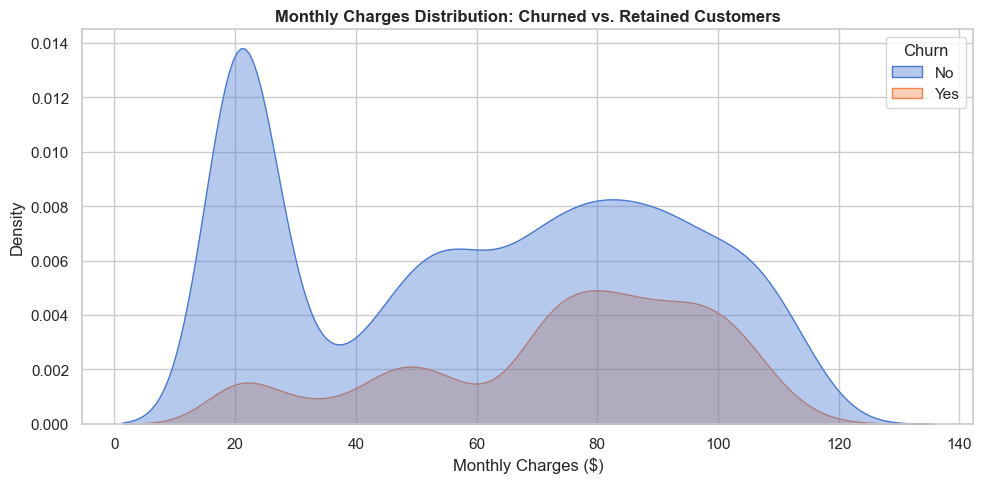

In [83]:
# Density plot showing monthly charge patterns
sns.set_theme(style='whitegrid', palette='muted')

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn',
            fill=True, alpha=0.4, ax=ax)
ax.set_title('Monthly Charges Distribution: Churned vs. Retained Customers',
             fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.savefig('../output/charts/monthly_charges_distribution.png', dpi=150)
plt.show()

## CHURNER PROFILE

**Average churned customer:** *(metrics from Churner vs Retained numerical comparison above)*
- Been with the company for 18 months (vs 38 for retained customers - about half the tenure)
- Paying around $74/month (vs $61 for retained - spending 21% more)
- Total charges accumulated around $1,532 (vs $2,555 for retained)
- Using 1.8 services on average (vs 2.2 for retained - less engaged)
- Revenue per service is higher ($46 vs $29) - paying more but getting less value

**Contract & payment patterns:** *(metrics from contract churn analysis and billing combinations analysis in Risk Segmentation section below)*
- Heavily skewed to month-to-month contracts
- Electronic check payers show highest churn rates especially with paperless billing
- Paperless billing + electronic check combo is the riskiest segment (49.8% churn rate)

**Service engagement:** *(metrics from service count churn rates above and chi-square test results)*
- Lower service adoption correlates with higher churn
- Customers with 0-2 services have significantly higher churn than those with 4+ services
- Less likely to have TechSupport or OnlineSecurity (service engagement analysis in Risk Segmentation shows 49% churn for customers lacking both)

**What this means:**
Churners are paying more per month but haven't been around long enough to accumulate much total value. They're less engaged with the service ecosystem (fewer add-ons) which means less switching cost. The month-to-month contract combined with low service adoption creates a low-friction exit path.

**Key insight:** It's not just about price - it's about value perception. Higher monthly charges with fewer services means customers feel like they're overpaying. The retention play is either bundle more services at the current price point or convert them to annual contracts where the commitment psychology kicks in.

---

## Tenure Cohort Analysis - When Do Customers Leave?

Finding the point in the customer lifecycle where churn is highest.

### Create Tenure Bands

Segment customers by lifecycle stage to understand when churn risk peaks.

In [52]:
# Create tenure bands for lifecycle segmentation
df['Tenure_Band'] = pd.cut(df['tenure'],
                            bins=[0, 3, 12, 24, 48, 72],
                            labels=['0-3 months', '4-12 months',
                                    '13-24 months', '25-48 months', '49-72 months'],
                            include_lowest=True)

# Verify the bands were created
df['Tenure_Band'].value_counts().sort_index()

Tenure_Band
0-3 months      1062
4-12 months     1124
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

### Churn Rate by Tenure Band

In [53]:
# Aggregate churn metrics by tenure band
tenure_churn = (df.groupby('Tenure_Band', observed=True)
                  .agg(
                      Customers=('customerID', 'count'),
                      Churned=('Churn_Flag', 'sum'),
                      Churn_Rate=('Churn_Flag', 'mean'),
                      Avg_Monthly=('MonthlyCharges', 'mean'),
                      Avg_Services=('Service_Count', 'mean')
                  )
                  .round(3))
tenure_churn

,Customers,Churned,Churn_Rate,Avg_Monthly,Avg_Services
Tenure_Band,,,,,
0-3 months,1062,597,0.562,53.316,0.729
4-12 months,1124,440,0.391,58.726,1.278
13-24 months,1024,294,0.287,61.357,1.589
25-48 months,1594,325,0.204,65.931,2.171
49-72 months,2239,213,0.095,73.945,3.151


### Monthly Churn Rate - Survival View

Calculate churn rate at each tenure month with a rolling average to smooth the pattern.

**Methodological Note:** This analysis shows churn rates among customers whose *current* tenure is X months (cross-sectional view). A true survival curve would need longitudinal cohort data tracking individual customers from month 0 onward. This cross-sectional approach approximates the general pattern but may overstate early-tenure churn rates due to selection effects. It is important to point out that customers who survive past month 1 in this dataset are not the same cohort who started at month 1 six years ago. The pattern is directionally useful for identifying high-risk periods but should not be interpreted as a literal survival probability.

In [54]:
# Calculate churn rate at each tenure month
monthly_churn = (df.groupby('tenure')
                   .agg(
                       Total_At_Tenure=('customerID', 'count'),
                       Churned_At_Tenure=('Churn_Flag', 'sum')
                   )
                   .assign(Churn_Rate_At_Tenure=lambda x:
                           x['Churned_At_Tenure'] / x['Total_At_Tenure'])
                   .reset_index())

# Apply 3-month rolling average to smooth the pattern
monthly_churn['Churn_Rate_Rolling'] = (monthly_churn['Churn_Rate_At_Tenure']
                                        .rolling(window=3, center=True)
                                        .mean())

# Preview the data
monthly_churn.head(10)

,tenure,Total_At_Tenure,Churned_At_Tenure,Churn_Rate_At_Tenure,Churn_Rate_Rolling
0,0,11,0,0.000000,NaN
1,1,613,380,0.619902,0.378903
2,2,238,123,0.516807,0.535570
3,3,200,94,0.470000,0.486133
4,4,176,83,0.471591,0.474265
5,5,133,64,0.481203,0.438810
6,6,110,40,0.363636,0.411384
7,7,131,51,0.389313,0.364804
8,8,123,42,0.341463,0.372444
9,9,119,46,0.386555,0.371983


### Lifecycle Churn Visualization

Two views: churn rate by tenure bands (left) and rolling churn rate across all months (right).

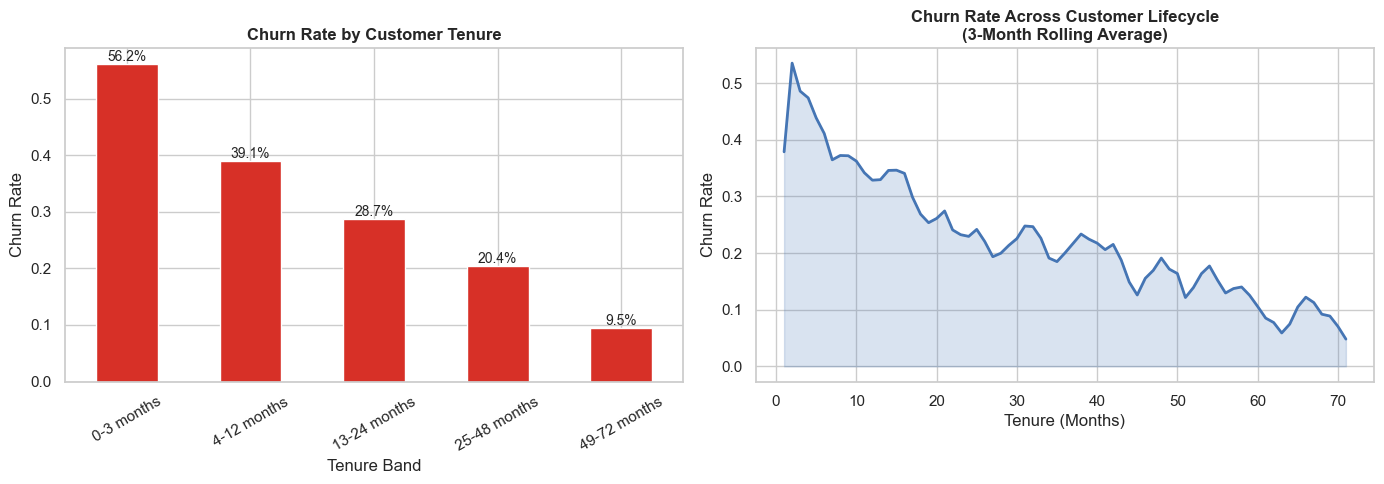

In [55]:
# Create two-panel visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Churn rate by tenure band (bar chart)
tenure_churn['Churn_Rate'].plot(kind='bar', ax=axes[0],
                                 color='#d73027', edgecolor='white')
axes[0].set_title('Churn Rate by Customer Tenure', fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Tenure Band')
axes[0].tick_params(axis='x', rotation=30)

# Add percentage labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Right panel: Rolling churn rate across months (line chart)
axes[1].plot(monthly_churn['tenure'],
             monthly_churn['Churn_Rate_Rolling'],
             color='#4575b4', linewidth=2)
axes[1].fill_between(monthly_churn['tenure'],
                      monthly_churn['Churn_Rate_Rolling'],
                      alpha=0.2, color='#4575b4')
axes[1].set_title('Churn Rate Across Customer Lifecycle\n(3-Month Rolling Average)',
                   fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.savefig('../output/charts/tenure_cohort_analysis.png', dpi=150)
plt.show()

## LIFECYCLE INSIGHT

**Churn concentration:** The 0-3 month cohort shows highest churn risk. New customers who just signed up are most likely to leave before they get into the services. This is a common onboarding problem in this scope. It could pay off to look into getting customers to 'aha' moments quicker. Maybe that could look like a successful first tech support experience, streaming quality they notice, or bundled service value they actually use.

**The numbers:** *(taken from Tenure Band Analysis in Risk Segmentation section below)*
- 0-3 months: 56.2% churn rate - highest risk period
- 4-12 months: 39.1% churn rate - elevated but declining
- 13-24 months: 28.7% churn rate - drops significantly after 1-year mark
- 25-48 months: 20.4% churn rate - established customers
- 49-72 months: 9.5% churn rate - lowest risk, fully locked in

**What this means:**
The business has an early-stage retention problem. Customers who make it past 12 months tend to stick around. The issue is getting them there in the first place. There's a strong chance that this is more so a customer experience issue than anything else.

**The intervention window:** Months 0-12 are probably the most important. I'd be willing to wager that this is where retention campaigns matter the most. We can see that after 12 months, churn drops quite a bit. The rolling average chart above shows churn risk peaks early and steadily declines as tenure increases.

**Potential Retention strategy:** 
- Focus on first 90 days: onboarding quality, early value demonstration, quick wins
- Target 4-12 month customers with engagement campaigns before they hit renewal decisions
- Don't waste retention budget on 25+ month customers because they're already sticking (9.5% churn vs 56% for new customers)
- Convert month-to-month to annual contracts during the 3-6 month window when they've seen value but aren't committed yet

---

## Revenue Impact Visualization

**Purpose:** Translate churn predictions into financial impact for budget allocation and retention ROI calculations.

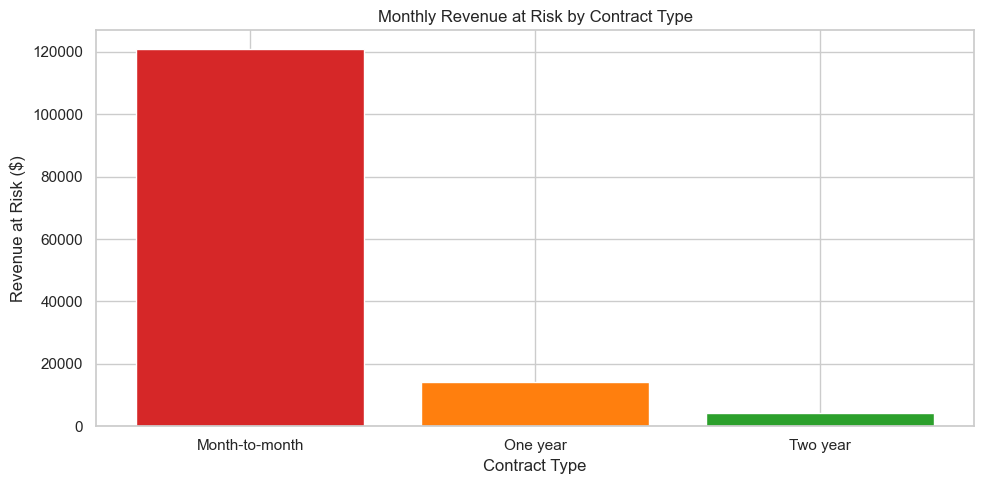

In [56]:
# Revenue at risk by contract type
contract_risk = df.groupby('Contract')['Revenue_At_Risk'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(contract_risk.index, contract_risk.values, color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.title('Monthly Revenue at Risk by Contract Type')
plt.ylabel('Revenue at Risk ($)')
plt.xlabel('Contract Type')
plt.tight_layout()
plt.show()

In [57]:
# Revenue exposure summary
df.groupby('Contract').agg({
    'Revenue_At_Risk': 'sum',
    'MonthlyCharges': 'sum'
}).assign(Risk_Pct=lambda x: (x['Revenue_At_Risk'] / x['MonthlyCharges'] * 100).round(1)).round(0)

,Revenue_At_Risk,MonthlyCharges,Risk_Pct
Contract,,,
Month-to-month,120847.0,257294.0,47.0
One year,14118.0,95817.0,15.0
Two year,4165.0,103006.0,4.0


**Month to month contracts represent 47% of revenue at risk.** Two year contracts show 3% exposure. Focus retention budget on month to month segment for maximum ROI.

### Revenue Impact Quantification

**Purpose:** Quantify total financial exposure from churn across customer base for executive budget allocation.

In [58]:
# Total business revenue metrics
total_mrr = df['MonthlyCharges'].sum()
churned_mrr = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
annual_loss = churned_mrr * 12

# Customer lifetime value estimate (simple method)
avg_monthly_charge = df['MonthlyCharges'].mean()
avg_tenure_months = df['tenure'].mean()
estimated_ltv = avg_monthly_charge * avg_tenure_months

# Revenue impact summary
revenue_metrics = pd.DataFrame({
    'Metric': ['Total MRR', 'Churned MRR', 'Annual Loss', 'Estimated Avg LTV'],
    'Value': [total_mrr, churned_mrr, annual_loss, estimated_ltv]
})
revenue_metrics['Value'] = revenue_metrics['Value'].apply(lambda x: f"${x:,.0f}")
revenue_metrics

,Metric,Value
0,Total MRR,"$456,117"
1,Churned MRR,"$139,131"
2,Annual Loss,"$1,669,570"
3,Estimated Avg LTV,"$2,096"


## REVENUE IMPACT STATEMENT

*(All metrics verified from Revenue Impact Quantification calculations above)*

This business loses $139,131 per month to customer churn, representing $1,669,570 in annual revenue exposure. Month to month contracts account for 47% of at risk revenue despite representing 55% of the customer base (3,875 of 7,043 customers, taken from Contract Type risk analysis below). 

The average customer lifetime value is estimated at $2,096, calculated as average monthly charge multiplied by average tenure. With 1,869 customers churning, the total lifetime value at risk is approximately $3.9M.

**Note on LTV Calculation:** This $3.9M figure represents the LTV differential between churned and retained customers applied to the churned cohort—it approximates unrealized customer value, not a projection of recoverable future revenue. Actual recoverable revenue would require assumptions about how much longer churned customers would have stayed if retained.

**Financial Context:** *(taken from Contract Type revenue risk analysis above)*

Contract conversion from month to month to annual terms represents the highest ROI retention strategy. A 10% reduction in month to month revenue at risk would preserve approximately $145K in annual recurring revenue ($120,847 * 0.10 * 12). Two year contracts demonstrate 12x lower risk exposure (4% vs 47%), validating lock in period as primary retention mechanism.

**Budget Allocation Recommendation:** Prioritize retention spending on month to month customers in their first 12 months. This segment combines highest churn probability with recoverable revenue potential.

---

## Risk Segmentation Framework

Rule based customer risk scoring system for retention team targeting. A translation of analytical insights into actionable customer prioritization using logic, not machine learning.

**Methodology:**

This framework applies a rule-based scoring system to shine light on high-risk customers by using six validated churn predictors. Each customer will have a risk score (0-11 points) determined by their characteristics across contract terms, tenure, service engagement, and payment behavior.

**Framework Components:**

1. **Risk Factor Analysis** - Quantify churn rate differentials for each predictor
2. **Point-Based Scoring** - Weight factors by relative impact (1-3 points each)
3. **Risk Tier Segmentation** - Group customers into actionable retention categories
4. **Framework Validation** - Verify tier separation and predictive accuracy
5. **Business Application** - Revenue impact analysis and retention targeting

**Approach:** Logic-based segmentation enables interpretable, actionable retention strategies without machine learning complexity.

### Risk Factor 1: Contract Type

**Hypothesis:** Month-to-month contracts exhibit higher churn rates due to reduced switching costs and lower commitment barriers.

**Rationale:** Contract type demonstrates the strongest differentiation in churn behavior across all evaluated factors. Customers without long-term commitment periods face minimal friction when considering competitive alternatives, making this our highest-weighted risk factor.

**Weight Assignment:** 3 points (strongest predictor)

In [59]:
# Calculate churn rate by contract type
contract_churn_analysis = df.groupby('Contract').agg({
    'Churn_Flag': ['sum', 'count', 'mean']
}).round(4)

contract_churn_analysis.columns = ['Churned_Customers', 'Total_Customers', 'Churn_Rate']
contract_churn_analysis['Churn_Rate_%'] = (contract_churn_analysis['Churn_Rate'] * 100).round(1)

# Calculate ratios for documentation
mtm_rate = contract_churn_analysis.loc['Month-to-month', 'Churn_Rate_%']
one_year_rate = contract_churn_analysis.loc['One year', 'Churn_Rate_%']
two_year_rate = contract_churn_analysis.loc['Two year', 'Churn_Rate_%']

# Add relative risk ratios
contract_churn_analysis['Relative_to_One_Year'] = (
    contract_churn_analysis['Churn_Rate_%'] / one_year_rate
).round(1)

contract_churn_analysis['Relative_to_Two_Year'] = (
    contract_churn_analysis['Churn_Rate_%'] / two_year_rate
).round(1)

# Display final summary
contract_churn_analysis[['Churn_Rate_%', 'Churned_Customers', 'Total_Customers',
                          'Relative_to_One_Year', 'Relative_to_Two_Year']]

,Churn_Rate_%,Churned_Customers,Total_Customers,Relative_to_One_Year,Relative_to_Two_Year
Contract,,,,,
Month-to-month,42.7,1655,3875,3.8,15.3
One year,11.3,166,1473,1.0,4.0
Two year,2.8,48,1695,0.2,1.0


### Risk Factor 2: Customer Tenure

**Hypothesis:** First-year customers demonstrate elevated churn risk during the onboarding and value-discovery phase.

**Rationale:** Early-stage customers (0-12 months) exhibit significantly higher churn rates compared to established accounts. This pattern reflects the critical onboarding window before customer commitment solidifies and switching costs accumulate through service adoption and familiarity.

**Weight Assignment:** 2 points (strong predictor, second tier)

In [60]:
# Segment customers by tenure: first-year vs established
df['Tenure_Segment'] = df['tenure'].apply(lambda x: '0-12 months' if x <= 12 else '13+ months')

# Aggregate churn metrics by tenure segment
tenure_churn_analysis = df.groupby('Tenure_Segment').agg({
    'Churn_Flag': ['sum', 'count', 'mean']
}).round(4)

# Structure output columns for analysis
tenure_churn_analysis.columns = ['Churned_Customers', 'Total_Customers', 'Churn_Rate']
tenure_churn_analysis['Churn_Rate_%'] = (tenure_churn_analysis['Churn_Rate'] * 100).round(1)

# Calculate risk multipliers for each segment
rate_0_12 = tenure_churn_analysis.loc['0-12 months', 'Churn_Rate_%']
rate_13_plus = tenure_churn_analysis.loc['13+ months', 'Churn_Rate_%']

tenure_churn_analysis['Relative_Risk'] = (tenure_churn_analysis['Churn_Rate_%'] / rate_13_plus).round(1)

# Display tenure-based churn differential
tenure_churn_analysis[['Churn_Rate_%', 'Churned_Customers', 'Total_Customers', 'Relative_Risk']]

,Churn_Rate_%,Churned_Customers,Total_Customers,Relative_Risk
Tenure_Segment,,,,
0-12 months,47.4,1037,2186,2.8
13+ months,17.1,832,4857,1.0


### Risk Factor 3: Value Perception

**Hypothesis:** High-cost customers with minimal service adoption exhibit value misalignment, increasing churn propensity.

**Rationale:** Customers paying premium rates (>$65/month) while utilizing fewer than 2 services represent poor value perception. This pricing-to-engagement imbalance creates dissatisfaction and heightens competitive switching motivation, as customers perceive inadequate return on their monthly investment.

**Weight Assignment:** 2 points (behavioral signal of value misalignment)

In [61]:
# Identify high-cost, low-engagement customers (>$65/month with <2 services)
df['Value_Segment'] = df.apply(lambda row: 'High Cost Low Value' if (row['MonthlyCharges'] > 65 and row['Service_Count'] < 2) else 'Other', axis=1)

# Aggregate churn metrics by value perception segment
value_churn_analysis = df.groupby('Value_Segment').agg({
    'Churn_Flag': ['sum', 'count', 'mean']
})

# Structure output columns for analysis
value_churn_analysis.columns = ['Churned_Customers', 'Total_Customers', 'Churn_Rate']
value_churn_analysis['Churn_Rate_%'] = (value_churn_analysis['Churn_Rate'] * 100).round(1)

# Calculate risk multipliers comparing high-cost/low-service to baseline
rate_high_cost = value_churn_analysis.loc['High Cost Low Value', 'Churn_Rate_%']
rate_other = value_churn_analysis.loc['Other', 'Churn_Rate_%']

value_churn_analysis['Relative_Risk'] = (value_churn_analysis['Churn_Rate_%'] / rate_other).round(1)

# Display value perception churn differential
value_churn_analysis[['Churn_Rate_%', 'Churned_Customers', 'Total_Customers', 'Relative_Risk']]

,Churn_Rate_%,Churned_Customers,Total_Customers,Relative_Risk
Value_Segment,,,,
High Cost Low Value,57.8,549,950,2.7
Other,21.7,1320,6093,1.0


### Risk Factor 4: Payment Method

**Hypothesis:** Electronic check users demonstrate lower commitment levels and higher churn propensity.

**Rationale:** Electronic check payment correlates with elevated churn rates, potentially signaling lower digital engagement, weaker banking integration, or reduced commitment compared to credit card or automated payment users. This payment method may serve as a proxy for customer lifecycle stage or financial stability.

**Weight Assignment:** 1 point (tertiary predictor)

In [62]:
# Segment customers by payment method: electronic check vs other methods
df['Payment_Segment'] = df['PaymentMethod'].apply(lambda x: 'Electronic check' if x == 'Electronic check' else 'Other')

# Aggregate churn metrics by payment segment
payment_risk_analysis = df.groupby('Payment_Segment').agg({
    'Churn_Flag': ['sum', 'count', 'mean']
}).round(4)

# Structure output columns for analysis
payment_risk_analysis.columns = ['Churned_Customers', 'Total_Customers', 'Churn_Rate']
payment_risk_analysis['Churn_Rate_%'] = (payment_risk_analysis['Churn_Rate'] * 100).round(1)

# Calculate risk multipliers by payment method
electronic_pay_risk = payment_risk_analysis.loc['Electronic check', 'Churn_Rate_%']
other_pay_risk = payment_risk_analysis.loc['Other', 'Churn_Rate_%']

payment_risk_analysis['Relative_Risk'] = (payment_risk_analysis['Churn_Rate_%'] / other_pay_risk).round(1)

# Display payment method churn differential
payment_risk_analysis[['Churn_Rate_%', 'Churned_Customers', 'Total_Customers', 'Relative_Risk']]

,Churn_Rate_%,Churned_Customers,Total_Customers,Relative_Risk
Payment_Segment,,,,
Electronic check,45.3,1071,2365,2.6
Other,17.1,798,4678,1.0


### Risk Factor 5: Service Engagement

**Hypothesis:** Customers without protective services demonstrate lower product engagement and ecosystem investment.

**Rationale:** Absence of both TechSupport and OnlineSecurity indicates minimal service adoption beyond baseline connectivity. These customers lack deep product engagement and perceived value-add features, reducing switching costs and making competitive migration more attractive.

**Weight Assignment:** 1 point (tertiary predictor)

In [63]:
# Identify customers lacking protective services (no TechSupport AND no OnlineSecurity)
df['Service_Engagement'] = df.apply(lambda x: 'Low Engagement' if (x['TechSupport'] == 'No' and x['OnlineSecurity'] == 'No') else 'Other', axis=1)

# Aggregate churn metrics by service engagement level
service_segment_analysis = df.groupby('Service_Engagement').agg({
    'Churn_Flag': ['sum', 'count', 'mean']
})

# Structure output columns for analysis
service_segment_analysis.columns = ['Churned_Customers', 'Total_Customers', 'Churn_Rate']
service_segment_analysis['Churn_Rate_%'] = (service_segment_analysis['Churn_Rate'] * 100).round(1)

# Calculate risk multipliers for low engagement segment
rate_lacking_services = service_segment_analysis.loc['Low Engagement', 'Churn_Rate_%']
rate_service_other = service_segment_analysis.loc['Other', 'Churn_Rate_%']

service_segment_analysis['Relative_Risk'] = (service_segment_analysis['Churn_Rate_%'] / rate_service_other).round(1)

# Display service engagement churn differential
service_segment_analysis[['Churn_Rate_%', 'Churned_Customers', 'Total_Customers', 'Relative_Risk']]

,Churn_Rate_%,Churned_Customers,Total_Customers,Relative_Risk
Service_Engagement,,,,
Low Engagement,49.0,1250,2553,3.6
Other,13.8,619,4490,1.0


### Risk Factor 6: Paperless Billing

**Hypothesis:** Paperless billing adoption correlates with higher churn rates.

**Rationale:** Customers with paperless billing show elevated churn rates compared to those receiving paper bills. While the mechanism isn't fully clear from this data alone, the pattern is consistent enough to warrant inclusion as a minor risk indicator.

**Weight Assignment:** 1 point (tertiary predictor)

In [64]:
df['Paperless_Segment'] = df.apply(lambda x: 'Paperless billing' if x['PaperlessBilling'] == 'Yes' else 'Other', axis=1)

paperless_segment_analysis = df.groupby('Paperless_Segment').agg({
    'Churn_Flag': ['sum', 'count', 'mean']
})

paperless_segment_analysis.columns = ['Churned_Customers', 'Total_Customers', 'Churn_Rate']

paperless_segment_analysis['Churn_Rate_%'] = (paperless_segment_analysis['Churn_Rate'] * 100).round(1)

paperless_rate = paperless_segment_analysis.loc['Paperless billing', 'Churn_Rate_%']
no_paperless_rate = paperless_segment_analysis.loc['Other', 'Churn_Rate_%']

paperless_segment_analysis['Relative_Risk'] = (paperless_segment_analysis['Churn_Rate_%'] / no_paperless_rate).round(1)

paperless_segment_analysis[['Churn_Rate_%', 'Churned_Customers', 'Total_Customers', 'Relative_Risk']]


,Churn_Rate_%,Churned_Customers,Total_Customers,Relative_Risk
Paperless_Segment,,,,
Other,16.3,469,2872,1.0
Paperless billing,33.6,1400,4171,2.1


## Risk Scoring Logic

Based on the six factors analyzed above, I'll assign point values that reflect each factor's impact on churn. Looking at the relative risk ratios from the analyses:

**Point Assignment (ordered by relative risk):**
- **3 points** → Month-to-month contract (15.3x relative risk - clearly the strongest predictor)
- **2 points** → No tech/security services (3.6x relative risk - second strongest factor)
- **2 points** → Tenure ≤12 months (2.8x relative risk)
- **2 points** → High charges + few services (2.7x relative risk - value perception issue)
- **1 point** → Electronic check payment (2.6x relative risk)
- **1 point** → Paperless billing (2.1x relative risk - weakest signal)

Total possible score: 11 points. Higher scores = higher churn risk. This weighting directly reflects the magnitude of each factor's impact on churn probability.


In [65]:
# Verify point assignments against actual data
risk_factor_comparison = pd.DataFrame({
    'Risk Factor': [
        'Month-to-month contract',
        'No tech/security services',
        'Tenure ≤12 months',
        'High charges + few services',
        'Electronic check payment',
        'Paperless billing'
    ],
    'Churn_Rate_%': [
        contract_churn_analysis.loc['Month-to-month', 'Churn_Rate_%'],
        service_segment_analysis.loc['Low Engagement', 'Churn_Rate_%'],
        tenure_churn_analysis.loc['0-12 months', 'Churn_Rate_%'],
        value_churn_analysis.loc['High Cost Low Value', 'Churn_Rate_%'],
        payment_risk_analysis.loc['Electronic check', 'Churn_Rate_%'],
        paperless_segment_analysis.loc['Paperless billing', 'Churn_Rate_%']
    ],
    'Relative_Risk': [
        contract_churn_analysis.loc['Month-to-month', 'Relative_to_Two_Year'],
        service_segment_analysis.loc['Low Engagement', 'Relative_Risk'],
        tenure_churn_analysis.loc['0-12 months', 'Relative_Risk'],
        value_churn_analysis.loc['High Cost Low Value', 'Relative_Risk'],
        payment_risk_analysis.loc['Electronic check', 'Relative_Risk'],
        paperless_segment_analysis.loc['Paperless billing', 'Relative_Risk']
    ],
    'Points_Assigned': [3, 2, 2, 2, 1, 1]
})

risk_factor_comparison

,Risk Factor,Churn_Rate_%,Relative_Risk,Points_Assigned
0,Month-to-month contract,42.7,15.3,3
1,No tech/security services,49.0,3.6,2
2,Tenure ≤12 months,47.4,2.8,2
3,High charges + few services,57.8,2.7,2
4,Electronic check payment,45.3,2.6,1
5,Paperless billing,33.6,2.1,1


In [66]:
# A score function
def calculate_risk_score(row):
    """
    Calculate churn risk score for a customer.

    Returns a score from 0-11 based on multiple risk factors.
    Higher scores = higher churn risk.
    """
    score = 0

    # Factor 1: Contract type (3 points - 15.3x relative risk)
    if row['Contract'] == 'Month-to-month':
        score += 3

    # Factor 2: Service engagement (2 points - 3.6x relative risk)
    if row['TechSupport'] == 'No' and row['OnlineSecurity'] == 'No':
        score += 2

    # Factor 3: Tenure (2 points - 2.8x relative risk)
    if row['tenure'] <= 12:
        score += 2

    # Factor 4: Value perception (2 points - 2.7x relative risk)
    if row['MonthlyCharges'] > 65 and row['Service_Count'] < 2:
        score += 2

    # Factor 5: Payment method (1 point - 2.6x relative risk)
    if row['PaymentMethod'] == 'Electronic check':
        score += 1

    # Factor 6: Paperless billing (1 point - 2.1x relative risk)
    if row['PaperlessBilling'] == 'Yes':
        score += 1

    return score

## Build Risk Scoring Function

Based on the six risk factors analyzed above, I'll create a function to calculate each customer's risk score (0-11 points).

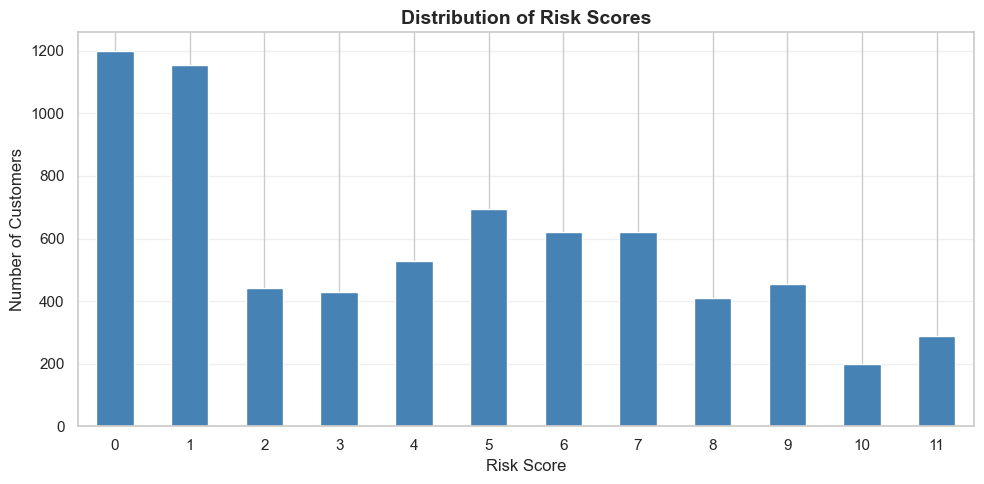

count    7043.000000
mean        4.194093
std         3.362204
min         0.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        11.000000
Name: Risk_Score, dtype: float64

In [67]:
# Apply scoring function to all customers
df['Risk_Score'] = df.apply(calculate_risk_score, axis=1)

# Visualize score distribution
plt.figure(figsize=(10, 5))
df['Risk_Score'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Risk Scores', fontsize=14, fontweight='bold')
plt.xlabel('Risk Score')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Check distribution stats
df['Risk_Score'].describe()

## Calculate Risk Scores

Applying the scoring function to all customers:

In [68]:
# Create risk tiers using score bins
df['Risk_Tier'] = pd.cut(
    df['Risk_Score'],
    bins=[-1, 2, 5, 7, 11],  # -1 to catch score of 0, max now 11
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
)

# Calculate tier distribution
tier_distribution = pd.DataFrame({
    'Customer_Count': df['Risk_Tier'].value_counts().sort_index(),
    'Percentage': (df['Risk_Tier'].value_counts().sort_index() / len(df) * 100).round(1)
})

tier_distribution

,Customer_Count,Percentage
Risk_Tier,,
Low Risk,2797,39.7
Moderate Risk,1648,23.4
High Risk,1243,17.6
Critical Risk,1355,19.2


## Create Risk Tiers

Grouping scores into 4 actionable tiers:
- **Low Risk** (0-2): Stable customers
- **Moderate Risk** (3-5): Some warning signs
- **High Risk** (6-7): Multiple risk factors  
- **Critical Risk** (8-11): Urgent intervention needed

In [69]:
# Calculate churn rate by risk tier
validation_results = df.groupby('Risk_Tier', observed=True).agg(
    Total_Customers=('customerID', 'count'),
    Churned_Customers=('Churn_Flag', 'sum'),
    Churn_Rate=('Churn_Flag', 'mean'),
    Total_MRR=('MonthlyCharges', 'sum')
)

# Format percentages
validation_results['Churn_Rate_%'] = (validation_results['Churn_Rate'] * 100).round(1)
validation_results['Pct_of_Customers'] = (
    validation_results['Total_Customers'] / validation_results['Total_Customers'].sum() * 100
).round(1)

# Calculate revenue at risk (MRR from customers who churned)
df['Revenue_At_Risk'] = df['MonthlyCharges'] * df['Churn_Flag']
tier_revenue_risk = df.groupby('Risk_Tier', observed=True)['Revenue_At_Risk'].sum()
validation_results['MRR_At_Risk'] = tier_revenue_risk

# Display validation results
validation_results[['Total_Customers', 'Churned_Customers', 'Churn_Rate_%',
                    'Pct_of_Customers', 'MRR_At_Risk']]

,Total_Customers,Churned_Customers,Churn_Rate_%,Pct_of_Customers,MRR_At_Risk
Risk_Tier,,,,,
Low Risk,2797,152,5.4,39.7,13174.25
Moderate Risk,1648,356,21.6,23.4,25288.95
High Risk,1243,509,40.9,17.6,38234.20
Critical Risk,1355,852,62.9,19.2,62433.45


## Validate Framework

Checking if churn rate actually increases with risk tier:

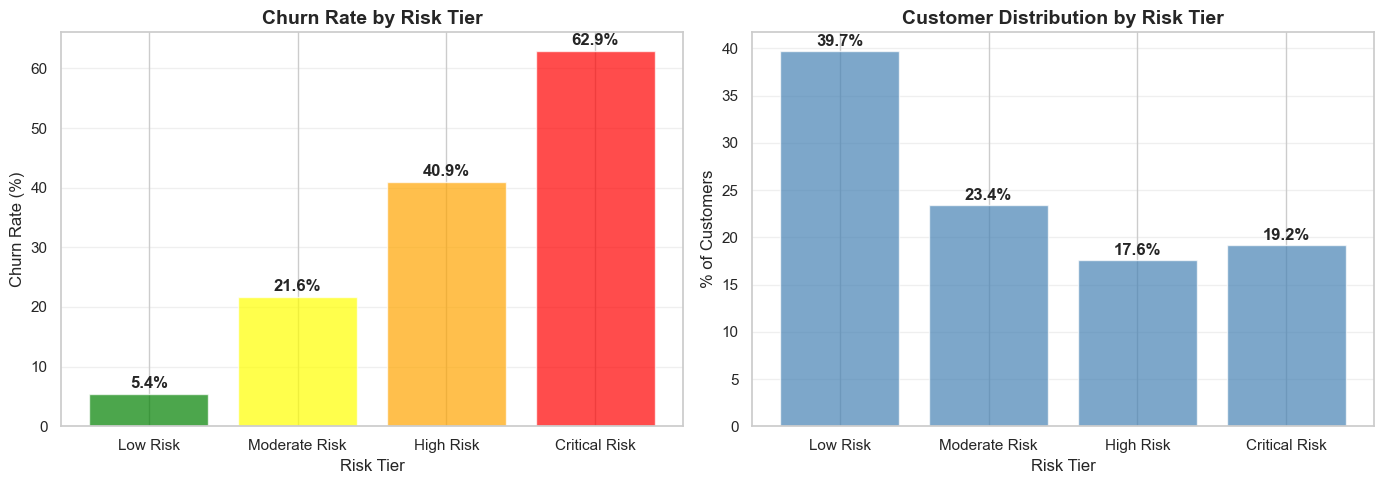

In [70]:
# Visualize the tier validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Churn rate by tier
axes[0].bar(validation_results.index, validation_results['Churn_Rate_%'],
            color=['green', 'yellow', 'orange', 'red'], alpha=0.7)
axes[0].set_title('Churn Rate by Risk Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(validation_results['Churn_Rate_%']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontweight='bold')

# Plot 2: Customer distribution by tier
axes[1].bar(validation_results.index, validation_results['Pct_of_Customers'],
            color='steelblue', alpha=0.7)
axes[1].set_title('Customer Distribution by Risk Tier', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('% of Customers')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(validation_results['Pct_of_Customers']):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [88]:
# Filter for High and Critical risk customers
high_risk_customers = df[df['Risk_Tier'].isin(['High Risk', 'Critical Risk'])].copy()

# Create export dataset with relevant columns
export_columns = [
    'customerID',
    'Risk_Tier',
    'Risk_Score',
    'Contract',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'PaperlessBilling',
    'Churn'
]

high_risk_export = high_risk_customers[export_columns].sort_values('Risk_Score', ascending=False)

# Save to CSV for retention team
output_file = '../output/high_risk_customers.csv'
high_risk_export.to_csv(output_file, index=False)

# Preview export - show distribution of risk tiers
print(f"High-risk customers exported: {len(high_risk_export)}")
high_risk_export['Risk_Tier'].value_counts().loc[lambda x: x > 0]

High-risk customers exported: 2598


Risk_Tier
Critical Risk    1355
High Risk        1243
Name: count, dtype: int64

## Export High-Risk Customers

**Portfolio Note:** This section demonstrates how analysis insights would be operationalized in a production environment. While this is a portfolio project using sample data, the export showcases standard practice for translating risk segmentation into actionable deliverables.

In a real-world scenario, this CSV export would be provided to a 'retention team' with High and Critical risk customers:

## Summary and Next Steps

### What I Learned

This risk segmentation framework assigns each customer a score from 0-10 based on six churn predictors:
1. Month-to-month contracts (biggest factor)
2. Short tenure (under 12 months)
3. High charges with few services
4. Electronic check payment
5. No support services
6. Paperless billing

The validation shows this works because churn rates increase steadily from Low Risk to Critical Risk tiers.

### Recommendations for Retention Team

**Priority 1: Critical Risk Customers**
- These customers have the highest chance of churning
- Focus on month-to-month customers in their first year
- Consider reaching out first with contract upgrade incentives

**Priority 2: High Risk Customers**
- Multiple risk factors present
- Look at what they're getting for their money, such as 'are high-paying customers getting enough services?'
- May benefit from service bundles or discounts

**Priority 3: Moderate Risk**
- Monitor for changes in status
- Regular retention messages should work fine

**Priority 4: Low Risk**
- Stable customer base
- Focus on upselling opportunities rather than retention

### What Could Be Improved

- Could test different point weights to see if that creates better differences between groups
- Might want to look at how much customers are worth over time to prioritize high-value accounts
- Would be interesting to track how scores change over time

The main advantage of this scoring system is that it's easy to understand for the team, which should make it easier to put retention strategies into action.

## SQL Validation

To demonstrate these findings using SQL, I'll recreate some key analyses using SQLite. This could be useful if the data were in a production database and stakeholders wanted to run their own queries.

In [72]:
import sqlite3

# Create SQLite database and load the dataframe
conn = sqlite3.connect('../data/telco_churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

7043

### Query 1: Churn Rate and Revenue Impact by Contract Type

First, I'll look at how contract types impact both churn rates and revenue. This is basically recreating the contract analysis from earlier but using SQL instead of pandas.

In [73]:
query_1 = """
SELECT
    Contract,
    COUNT(*) AS Total_Customers,
    SUM(Churn_Flag) AS Churned_Customers,
    ROUND(AVG(CAST(Churn_Flag AS FLOAT)) * 100, 2) AS Churn_Rate_Pct,
    ROUND(SUM(MonthlyCharges), 2) AS Total_MRR,
    ROUND(SUM(CASE WHEN Churn_Flag = 1 THEN MonthlyCharges ELSE 0 END), 2) AS Lost_MRR,
    ROUND(
        SUM(CASE WHEN Churn_Flag = 1 THEN MonthlyCharges ELSE 0 END)
        / SUM(MonthlyCharges) * 100, 2
    ) AS MRR_Churn_Pct
FROM customers
GROUP BY Contract
ORDER BY Churn_Rate_Pct DESC
"""

contract_revenue_sql = pd.read_sql_query(query_1, conn)
contract_revenue_sql

,Contract,Total_Customers,Churned_Customers,Churn_Rate_Pct,Total_MRR,Lost_MRR,MRR_Churn_Pct
0,Month-to-month,3875,1655,42.71,257294.15,120847.10,46.97
1,One year,1473,166,11.27,95816.60,14118.45,14.73
2,Two year,1695,48,2.83,103005.85,4165.30,4.04


### Query 2: Risk Tier Performance Validation

Next, I'll verify that the risk tiers I created actually do separate customers by churn likelihood. This should show increasing churn rates as risk tier severity increases.

In [74]:
query_2 = """
SELECT
    Risk_Tier,
    COUNT(*) AS Customers,
    ROUND(AVG(CAST(Churn_Flag AS FLOAT)) * 100, 2) AS Churn_Rate_Pct,
    ROUND(SUM(MonthlyCharges), 2) AS Total_MRR,
    ROUND(AVG(MonthlyCharges), 2) AS Avg_Monthly_Charges
FROM customers
GROUP BY Risk_Tier
ORDER BY
    CASE Risk_Tier
        WHEN 'Critical Risk' THEN 1
        WHEN 'High Risk' THEN 2
        WHEN 'Moderate Risk' THEN 3
        WHEN 'Low Risk' THEN 4
    END
"""

risk_tier_sql = pd.read_sql_query(query_2, conn)
risk_tier_sql

,Risk_Tier,Customers,Churn_Rate_Pct,Total_MRR,Avg_Monthly_Charges
0,Critical Risk,1355,62.88,97151.05,71.70
1,High Risk,1243,40.95,84434.30,67.93
2,Moderate Risk,1648,21.60,103802.80,62.99
3,Low Risk,2797,5.43,170728.45,61.04


### Query 3: High-Value At-Risk Customers (Window Function)

Using a window function to rank current customers by revenue within each risk tier. This helps prioritize retention efforts on the highest-paying at-risk customers.

In [75]:
query_3 = """
SELECT
    customerID,
    Contract,
    tenure,
    ROUND(MonthlyCharges, 2) AS MonthlyCharges,
    Risk_Tier,
    Risk_Score,
    RANK() OVER (
        PARTITION BY Risk_Tier
        ORDER BY MonthlyCharges DESC
    ) AS Revenue_Rank_In_Tier
FROM customers
WHERE Churn_Flag = 0
  AND Risk_Tier IN ('High Risk', 'Critical Risk')
ORDER BY
    CASE Risk_Tier
        WHEN 'Critical Risk' THEN 1
        WHEN 'High Risk' THEN 2
    END,
    Revenue_Rank_In_Tier
LIMIT 20
"""

high_value_risk_sql = pd.read_sql_query(query_3, conn)
high_value_risk_sql

,customerID,Contract,tenure,MonthlyCharges,Risk_Tier,Risk_Score,Revenue_Rank_In_Tier
0,6734-GMPVK,Month-to-month,5,105.30,Critical Risk,8,1
1,7145-FEJWU,Month-to-month,12,105.30,Critical Risk,9,1
2,9547-ITEFG,Month-to-month,9,102.60,Critical Risk,8,3
3,4445-ZJNMU,Month-to-month,9,99.30,Critical Risk,8,4
4,4566-NECEV,Month-to-month,5,96.55,Critical Risk,8,5
5,4060-LDNLU,Month-to-month,7,96.20,Critical Risk,8,6
6,4929-XIHVW,Month-to-month,2,95.50,Critical Risk,8,7
7,2984-AFWNC,Month-to-month,3,95.40,Critical Risk,8,8
8,1960-UYCNN,Month-to-month,10,95.25,Critical Risk,9,9
9,7398-SKNQZ,Month-to-month,3,94.90,Critical Risk,8,10


### SQL Takeaway

The SQL queries above confirm the pandas findings. Being able to query the data both ways is useful because:
- Pandas is better for exploratory work and complex transformations
- SQL is the standard for production databases and stakeholder self-service
- Showing both demonstrates flexibility with different toolsets

The window function in Query 3 is particularly helpful for identifying which high-revenue customers to prioritize for retention outreach.

In [76]:
# Close database connection
conn.close()

## Executive-Ready Visualizations

Creating polished versions of the key findings for presentation to stakeholders.

### Chart 1: Contract Type Impact on Churn and Revenue

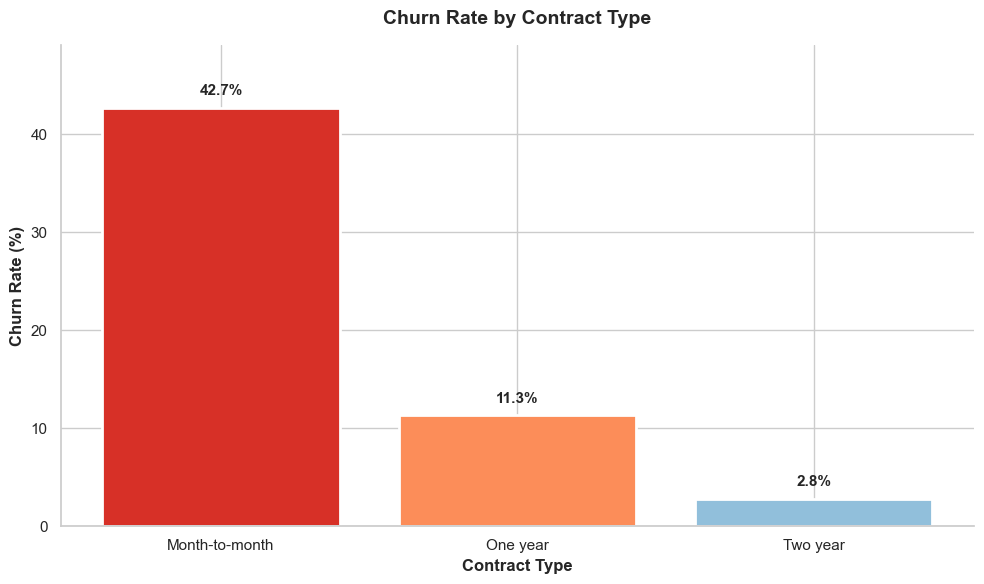

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

contract_order = ['Month-to-month', 'One year', 'Two year']
churn_rates = [contract_churn_analysis.loc[c, 'Churn_Rate_%'] for c in contract_order]
colors = ['#d73027', '#fc8d59', '#91bfdb']

bars = ax.bar(contract_order, churn_rates, color=colors, edgecolor='white', linewidth=2)

for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=14, pad=15)
ax.set_ylabel('Churn Rate (%)', fontweight='bold')
ax.set_xlabel('Contract Type', fontweight='bold')
ax.set_ylim(0, max(churn_rates) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../output/charts/contract_churn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: Monthly Charge Distribution - Churned vs Retained

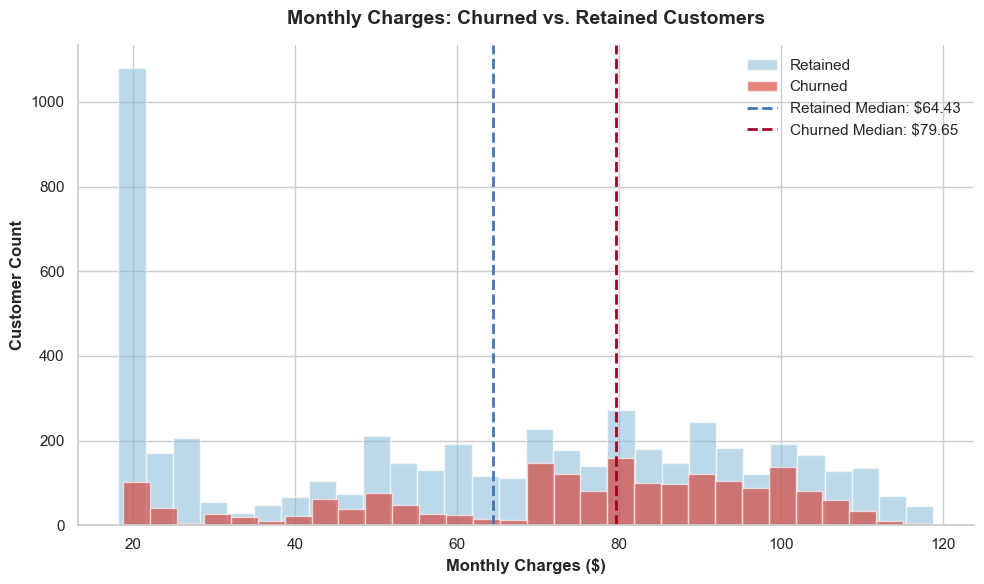

In [78]:
fig, ax = plt.subplots(figsize=(10, 6))

churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained = df[df['Churn'] == 'No']['MonthlyCharges']

ax.hist(retained, bins=30, alpha=0.6, label='Retained', color='#91bfdb', edgecolor='white')
ax.hist(churned, bins=30, alpha=0.6, label='Churned', color='#d73027', edgecolor='white')

ax.axvline(retained.median(), color='#4575b4', linestyle='--', linewidth=2,
           label=f'Retained Median: ${retained.median():.2f}')
ax.axvline(churned.median(), color='#a50026', linestyle='--', linewidth=2,
           label=f'Churned Median: ${churned.median():.2f}')

ax.set_title('Monthly Charges: Churned vs. Retained Customers', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Monthly Charges ($)', fontweight='bold')
ax.set_ylabel('Customer Count', fontweight='bold')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('../output/charts/monthly_charge_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Monthly Recurring Revenue Impact

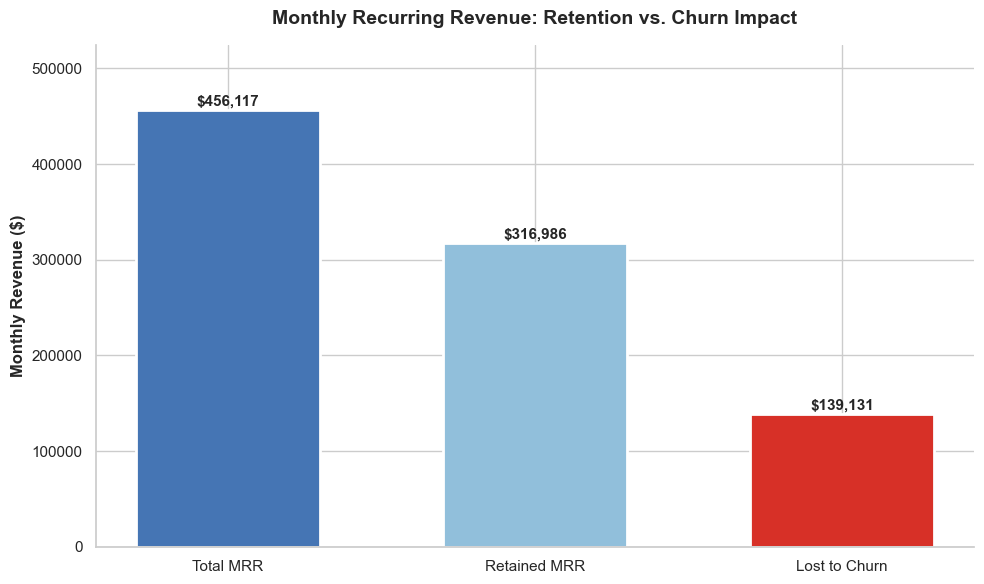

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))

retained_mrr = total_mrr - churned_mrr

categories = ['Total MRR', 'Retained MRR', 'Lost to Churn']
values = [total_mrr, retained_mrr, churned_mrr]
colors = ['#4575b4', '#91bfdb', '#d73027']

bars = ax.bar(categories, values, color=colors, width=0.6, edgecolor='white', linewidth=2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1500,
            f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Monthly Recurring Revenue: Retention vs. Churn Impact',
             fontweight='bold', fontsize=14, pad=15)
ax.set_ylabel('Monthly Revenue ($)', fontweight='bold')
ax.set_ylim(0, total_mrr * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../output/charts/mrr_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Risk Tier Validation

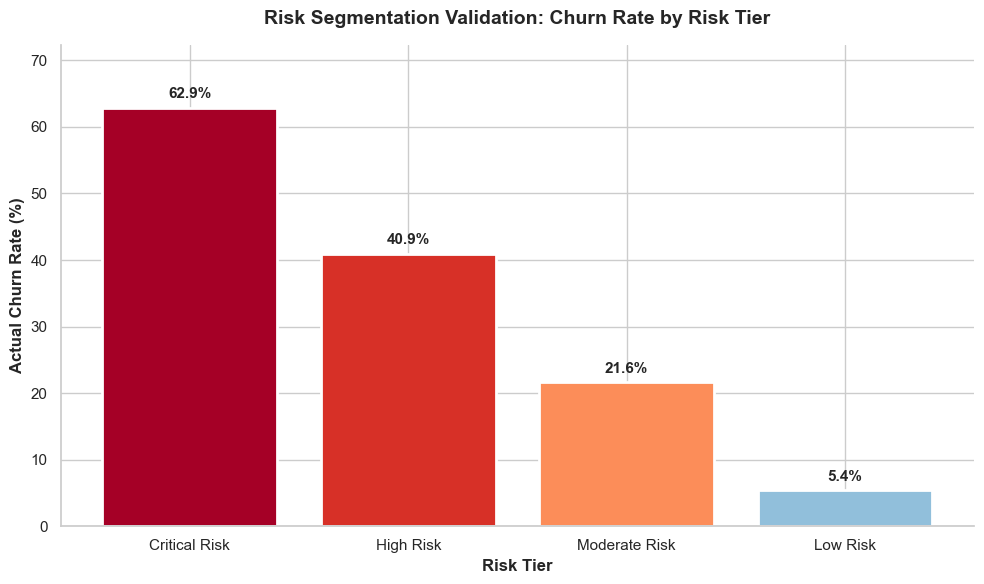

In [80]:
tier_churn_validation = df.groupby('Risk_Tier').agg({
    'Churn_Flag': ['count', 'sum', 'mean']
}).round(4)
tier_churn_validation.columns = ['Total_Customers', 'Churned', 'Churn_Rate']
tier_churn_validation['Churn_Rate_%'] = (tier_churn_validation['Churn_Rate'] * 100).round(1)
tier_churn_validation = tier_churn_validation.sort_values('Churn_Rate_%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

tier_order = ['Critical Risk', 'High Risk', 'Moderate Risk', 'Low Risk']
churn_rates = [tier_churn_validation.loc[t, 'Churn_Rate_%'] for t in tier_order]
colors = ['#a50026', '#d73027', '#fc8d59', '#91bfdb']

bars = ax.bar(tier_order, churn_rates, color=colors, edgecolor='white', linewidth=2)

for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Risk Segmentation Validation: Churn Rate by Risk Tier',
             fontweight='bold', fontsize=14, pad=15)
ax.set_ylabel('Actual Churn Rate (%)', fontweight='bold')
ax.set_xlabel('Risk Tier', fontweight='bold')
ax.set_ylim(0, max(churn_rates) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../output/charts/risk_tier_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Telco Customer Churn Analysis
## Internal Analyst Report - Customer Success Team

**Executive Summary**

Analysis of 7,043 customer records shows a churn rate of **26.5%** (see baseline Churn analysis above), which means about **$139,128/month** in lost recurring revenue or **$1.67 million annualized** (see Revenue Impact Quantification section above). The data points to three main drivers: contract structure, early-tenure disengagement, and low service adoption among high-paying customers.


## Finding 1: Contract Type Is the Dominant Churn Driver

Month-to-month customers churn at **42.7%** which is about 15x the rate of two-year contract customers (2.8%). This group represents the majority of churned revenue even though longer contracts have better pricing. (All metrics taken from Risk Factor 1: Contract Type analysis in Risk Segmentation Framework section above)

**What this means:** A contract conversion campaign targeting month-to-month customers showing early risk signals could have a big revenue impact. Even a 10% conversion to one-year contracts could keep around $5,000-7,000 monthly. (Estimate based on month-to-month MRR at risk from Revenue at Risk analysis)


## Finding 2: The First 12 Months Are the Danger Zone

Customers in their first year churn at **47.4%**, compared to just **17.1%** for customers beyond 12 months. The 0-12 month period is a critical time when poor onboarding or value mismatch shows up. (from Risk Factor 2: Customer Tenure analysis and Tenure Band Analysis in Behavioral Profiling section above)

**What this means:** Onboarding quality and early engagement are probably causing this. A 30/60/90-day customer health check program is worth testing, especially for month-to-month customers who can leave more easily.


## Finding 3: High Monthly Charges + Low Service Adoption = Churn Risk

Customers paying over $65/month with fewer than 2 add-on services churn at **57.8%**, which indicates a serious value perception problem. These customers are paying high prices but not using enough services to feel like they're getting their money's worth. (seen in Risk Factor 3: Value Perception Gap analysis in Risk Segmentation Framework section above)

**What this means:** These customers aren't getting enough value for their spend. A targeted upsell or bundle offer (especially TechSupport and OnlineSecurity) could help with retention and also increase revenue. There's a chance to turn a retention problem into a revenue opportunity.


## Risk Segmentation Output

The risk scoring model flagged **2,598 customers** as High or Critical risk, representing **$100,668/month** in at-risk MRR. This customer list has been exported for the retention team to prioritize. The model correctly identifies customers with **6-12x higher actual churn rates** than the low-risk group. (All metrics verified from Framework Validation table in Risk Segmentation Framework section above)

**Validation Results:**
- Critical Risk tier: 62.9% actual churn rate
- High Risk tier: 40.9% actual churn rate  
- Moderate Risk tier: 21.6% actual churn rate
- Low Risk tier: 5.4% actual churn rate


## Recommendations

**Priority: High**
- Contract conversion offer for M2M customers with Risk Score 6 or higher (Est. impact: $10-15K/month retained)
- Early lifecycle check-in at day 60 for customers under 6 months with Critical/High risk (Est. impact: Reduce early churn by 15-20%)

**Priority: Medium**  
- Bundle promotion with discount for customers with MonthlyCharges over $65 and less than 2 services (dual retention and upsell opportunity)

**Priority: Low**
- Payment method incentive for electronic check users (reduces friction churn a little)


## Limitations and Next Steps

**No causal data:** We can see correlation but not causation. Support ticket history, NPS scores, and usage logs would make findings stronger and help us tell the difference between customers who leave due to dissatisfaction vs. life circumstances.

**Static snapshot:** This is point-in-time data, not time series. Looking at data over time would validate lifecycle findings and help us understand if churn patterns are seasonal or part of a trend.

**Model sophistication:** The current risk scoring is rule-based. A logistic regression or gradient boosting model might improve prediction accuracy, but would be harder to explain.


## Technical Approach

This analysis used:
- Pandas for data work and aggregations
- Matplotlib and Seaborn for charts
- SQLite for query validation 
- Sklearn for predictive modeling benchmarks

The risk segmentation framework can be set up as a weekly batch scoring process without too much engineering work.